## Classification

Classification deal with qualitative data instead of quantitative data like we had in regression problems. The goal in a classification problem is to asigne a categoric label Y to a given input vector X. Why we cant use linear regression here as well and fit a lineare model to our data? 
1. Lineare regression models can not accomodate settings with more then two classes
2. a regression method wont provide meaningful estimates for Pr(Y|X).

## Logistic regression for classification
Logistic regression tries not to model the response Y for a given predictor X but models the probability Pr of Y belonging to a given class for a given X as input.

This is done using the logistic function 

$$

P(X) = \frac{e^{\beta_0 + \beta_1 X}}{1+e^{\beta_0 + \beta_1 X}}

$$

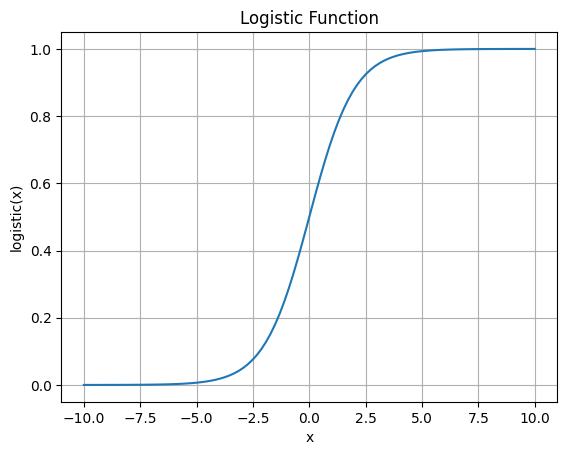

In [147]:
# plot the logistic function
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-10, 10, 100)
# without bias term beta_0 and beta_1 = 1
beta_0 = 0
beta_1 = 1
y = np.exp(beta_0 + beta_1 * x) / (1 + np.exp(beta_0 + beta_1 * x))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('logistic(x)')
plt.title('Logistic Function')
plt.grid()
plt.show()

## Logistic Regression: Step-by-Step Derivation and Interpretation

### 1. Problem setting

In a binary classification problem, the response variable takes values

$$
Y \in \{0,1\}.
$$

The goal is not to predict $Y$ directly, but to model the conditional probability

$$
P(Y = 1 \mid X = x).
$$

This probability must lie in the interval $[0,1]$, which a linear model cannot guarantee.

---

### 2. Linear model for the log-odds

Instead of assuming a linear relationship for the probability itself, logistic regression assumes a linear relationship for the **log-odds**:

$$
\log\left(
\frac{P(Y=1 \mid X=x)}{1 - P(Y=1 \mid X=x)}
\right)
=
\beta_0 + \beta_1 x.
$$

The left-hand side is called the **logit function**.

---

### 3. Solving for the probability

Exponentiating both sides gives

$$
\frac{P(Y=1 \mid X=x)}{1 - P(Y=1 \mid X=x)}
=
e^{\beta_0 + \beta_1 x}.
$$

Rearranging yields

$$
P(Y=1 \mid X=x)
=
\frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}.
$$

This is the **logistic (sigmoid) function**, which maps $\mathbb{R}$ to $(0,1)$.

---

### 4. Statistical model for the response

For each observation $(x_i, y_i)$, we assume

$$
Y_i \sim \text{Bernoulli}(p_i),
\quad
p_i = P(Y_i = 1 \mid X_i).
$$

Thus, the conditional probability mass function is

$$
P(Y_i = y_i \mid X_i)
=
p_i^{y_i}(1 - p_i)^{1 - y_i}.
$$

---

### 5. Likelihood function

Assuming independent observations, the likelihood of the parameters
$\beta = (\beta_0, \beta_1)$ is

$$
L(\beta)
=
\prod_{i=1}^{n}
p_i^{y_i} (1 - p_i)^{1 - y_i},
$$

where

$$
p_i
=
\frac{e^{\beta_0 + \beta_1 x_i}}{1 + e^{\beta_0 + \beta_1 x_i}}.
$$

---

### 6. Maximum likelihood estimation

The **maximum likelihood estimator** is defined as

$$
\hat\beta
=
\arg\max_{\beta} L(\beta).
$$

In practice, we maximize the log-likelihood

$$
\ell(\beta)
=
\sum_{i=1}^{n}
\left[
y_i \log p_i
+
(1 - y_i)\log(1 - p_i)
\right],
$$

which is numerically more stable and easier to optimize.

---

### 7. From probabilities to classification

After estimating $\hat\beta$, we obtain the fitted probabilities

$$
\hat p(x) = P(Y=1 \mid X=x).
$$

A common classification rule is

$$
\hat Y =
\begin{cases}
1, & \text{if } \hat p(x) > 0.5, \\
0, & \text{otherwise}.
\end{cases}
$$

---

### 8. Key interpretation

- Logistic regression models **probabilities**, not class labels.
- Maximum likelihood chooses parameters that make the observed labels most probable.
- Classification is a **separate decision step** applied to the estimated probabilities.

---

### 9. One-line summary

> Logistic regression models the log-odds of a binary response as a linear function of the predictors and estimates parameters by maximum likelihood.



# Estimating the logistic regression coefficients

To make predictions and fit the model we need to estimate $\beta_0 $ and $\beta_1$ from our dataset X and Y by maximizing the likelyhood function as described in step 6 above.


Converged after 559 iterations
Estimated coefficients (scaled space): [-5.87781532  2.5909417 ]


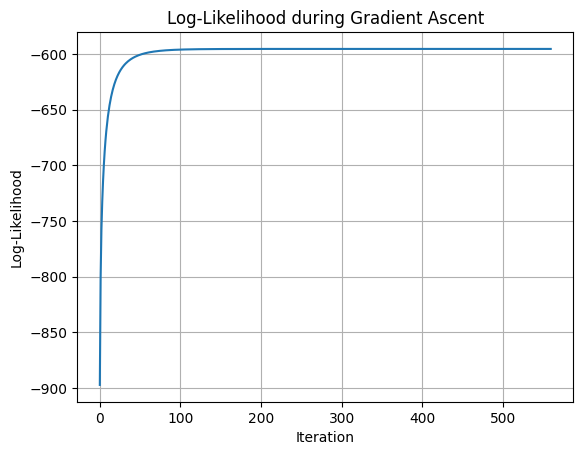

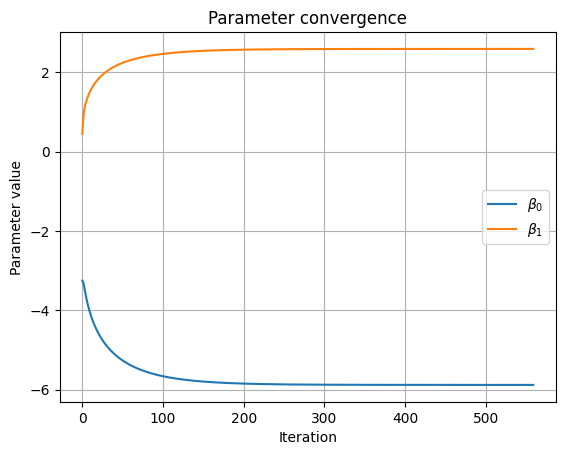

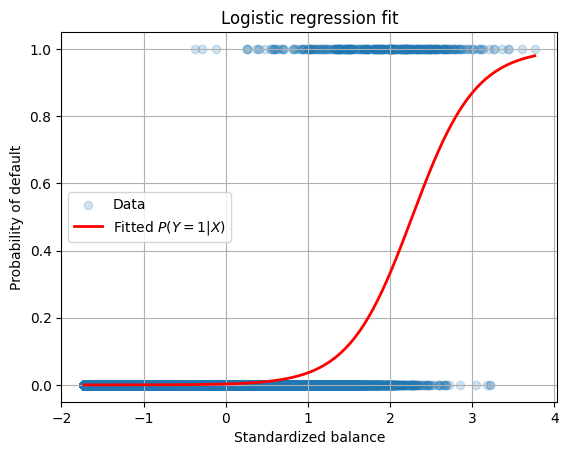

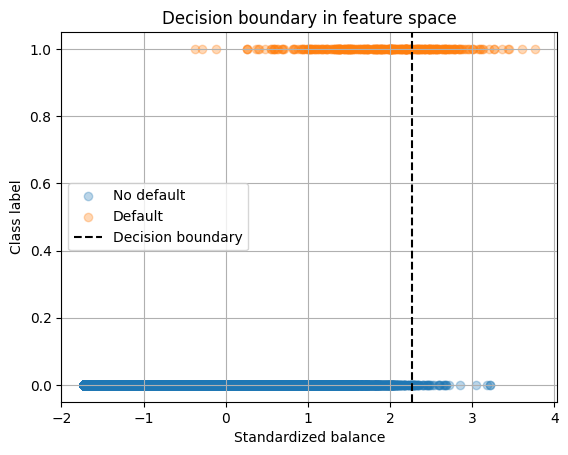

Test accuracy: 0.976
Unscaled coefficients:
beta_0 = -10.352590595355277
beta_1 = 0.00535660737861695
Standard Errors: [0.20578835 0.12053372]
Z-statistics: [-28.56243036  21.49557616]
P-values: [0. 0.]
Optimization terminated successfully.
         Current function value: 0.085054
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6998
Method:                           MLE   Df Model:                            1
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                  0.4497
Time:                        12:37:33   Log-Likelihood:                -595.38
converged:                       True   LL-Null:                       -1081.8
Covariance Type:            nonrobust   LLR p-value:                1.395e-213
                 coef    std err          z      P>|z|      [0

In [148]:
# Logistic Regression from scratch — stable + visualized
# ------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data

# -----------------------------
# 1. Load and prepare data
# -----------------------------
Default = load_data('Default')

# Predictor and response
X_raw = Default['balance'].values.astype(float)
y = (Default['default'] == 'Yes').astype(float).values

# Standardize predictor (CRUCIAL for stability)
X_mean = X_raw.mean()
X_std = X_raw.std()
X_scaled = (X_raw - X_mean) / X_std

# Design matrix with intercept
X = np.vstack([np.ones(len(X_scaled)), X_scaled]).T

# Train / test split
np.random.seed(0)
idx = np.random.permutation(len(X))
n_train = int(0.7 * len(X))

train_idx = idx[:n_train]
test_idx  = idx[n_train:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# -----------------------------
# 2. Logistic model components
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_likelihood(X, y, beta, eps=1e-9):
    p = sigmoid(X @ beta)
    p = np.clip(p, eps, 1 - eps)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

# -----------------------------
# 3. Gradient Ascent (stable)
# -----------------------------
beta_history = []
ll_history = []

def gradient_ascent(X, y, lr=0.001, max_iter=20000, tol=1e-6):
    beta = np.zeros(X.shape[1])
    
    for i in range(max_iter):
        p = sigmoid(X @ beta)
        grad = X.T @ (y - p)
        beta_new = beta + lr * grad
        
        ll = log_likelihood(X, y, beta_new)
        beta_history.append(beta_new.copy())
        ll_history.append(ll)
        
        if np.linalg.norm(beta_new - beta) < tol:
            print(f"Converged after {i} iterations")
            break
        
        beta = beta_new
    
    return beta

beta_hat = gradient_ascent(X_train, y_train)

print("Estimated coefficients (scaled space):", beta_hat)

# -----------------------------
# 4. Visualizations
# -----------------------------

# 4.1 Log-likelihood over iterations
plt.figure()
plt.plot(ll_history)
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood during Gradient Ascent")
plt.grid()
plt.show()

# 4.2 Parameter trajectory
beta_hist = np.array(beta_history)

plt.figure()
plt.plot(beta_hist[:, 0], label=r"$\beta_0$")
plt.plot(beta_hist[:, 1], label=r"$\beta_1$")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.title("Parameter convergence")
plt.legend()
plt.grid()
plt.show()

# 4.3 Data + fitted probability curve
x_plot = np.linspace(X_scaled.min(), X_scaled.max(), 300)
X_plot = np.vstack([np.ones(len(x_plot)), x_plot]).T
p_plot = sigmoid(X_plot @ beta_hat)

plt.figure()
plt.scatter(X_scaled, y, alpha=0.2, label="Data")
plt.plot(x_plot, p_plot, color="red", linewidth=2, label="Fitted $P(Y=1|X)$")
plt.xlabel("Standardized balance")
plt.ylabel("Probability of default")
plt.title("Logistic regression fit")
plt.legend()
plt.grid()
plt.show()

# 4.4 Decision boundary
decision_x = -beta_hat[0] / beta_hat[1]

plt.figure()
plt.scatter(X_scaled[y == 0], y[y == 0], alpha=0.3, label="No default")
plt.scatter(X_scaled[y == 1], y[y == 1], alpha=0.3, label="Default")
plt.axvline(decision_x, color="black", linestyle="--", label="Decision boundary")
plt.xlabel("Standardized balance")
plt.ylabel("Class label")
plt.title("Decision boundary in feature space")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 5. Test performance
# -----------------------------
p_test = sigmoid(X_test @ beta_hat)
y_pred = (p_test >= 0.5).astype(int)

accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy:.3f}")
beta0_scaled, beta1_scaled = beta_hat

beta1_unscaled = beta1_scaled / X_std
beta0_unscaled = beta0_scaled - beta1_scaled * X_mean / X_std

print("Unscaled coefficients:")
print("beta_0 =", beta0_unscaled)
print("beta_1 =", beta1_unscaled)

# now calculate the z statistic and p-value for beta_0 and beta_1
import scipy.stats as stats

def standard_errors(X, y, beta):
    p = sigmoid(X @ beta)
    W = np.diag(p * (1 - p))
    cov_matrix = np.linalg.inv(X.T @ W @ X)
    se = np.sqrt(np.diag(cov_matrix))
    return se

se_beta = standard_errors(X_train, y_train, beta_hat)
z_stats = beta_hat / se_beta
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))
print("Standard Errors:", se_beta)
print("Z-statistics:", z_stats)
print("P-values:", p_values)

# now compare it to statsmodels
import statsmodels.api as sm
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()
print(result.summary())



## Logistic Regression: Numerical Behavior and Interpretation

### What we observe

- The log-likelihood increases monotonically during gradient ascent,
  indicating correct optimization of the maximum likelihood objective.
- The parameter trajectories converge smoothly once the predictor
  variable is standardized.
- The fitted sigmoid curve represents the estimated conditional
  probability $P(Y=1 \mid X)$.
- The decision boundary corresponds to the point where
  $P(Y=1 \mid X) = 0.5$, i.e.
  $$
  \beta_0 + \beta_1 X = 0.
  $$

---

### Why fitting logistic regression is numerically difficult

#### 1. Exponential nonlinearity

The model contains the sigmoid function
$$
\sigma(z) = \frac{1}{1 + e^{-z}},
$$
which involves exponentials.
Large values of
$$
z = X\beta
$$
can easily lead to numerical overflow or vanishing gradients.

---

#### 2. Feature scale sensitivity

If $X$ has large magnitude (e.g. balances in the thousands),
then $X\beta$ becomes large even for moderate $\beta$,
making gradient-based optimization unstable.

---

#### 3. No closed-form solution

Unlike linear regression, logistic regression has no analytic
solution for $\hat\beta$.
Parameters must be found by iterative optimization.

---

#### 4. Likelihood geometry

The log-likelihood surface is concave but can be very flat
in some directions, leading to slow convergence without
proper scaling or step-size control.

---

### Why standardization fixes the problem

Standardizing the predictor
$$
X^{(s)} = \frac{X - \mu_X}{\sigma_X}
$$
ensures that:

- gradients have comparable magnitudes,
- learning rates are meaningful,
- numerical overflow is avoided.

This is why optimization converges reliably only after scaling.

---

### Back-transforming the coefficients

The fitted model on the standardized predictor is
$$
\log\frac{P(Y=1 \mid X)}{1 - P(Y=1 \mid X)}
=
\beta_0^{(s)} + \beta_1^{(s)} X^{(s)}.
$$

Substituting
$$
X^{(s)} = \frac{X - \mu_X}{\sigma_X}
$$
yields
$$
\log\frac{P(Y=1 \mid X)}{1 - P(Y=1 \mid X)}
=
\left(\beta_0^{(s)} - \beta_1^{(s)}\frac{\mu_X}{\sigma_X}\right)
+
\frac{\beta_1^{(s)}}{\sigma_X} X.
$$

Thus, the coefficients on the original scale are
$$
\beta_1 = \frac{\beta_1^{(s)}}{\sigma_X},
\qquad
\beta_0 = \beta_0^{(s)} - \beta_1^{(s)}\frac{\mu_X}{\sigma_X}.
$$

---

### Key takeaway

Logistic regression is statistically simple but numerically subtle.
Successful fitting requires:

- feature scaling,
- stable likelihood evaluation,
- careful optimization.

These issues arise from maximum likelihood estimation
with nonlinear link functions.


## Multiple Logistic regression

So far we only looked into logistic regression with maximum two classes or one binary class (yes, no) with one response X. To perform classification with multiple responses we need to advance the formular $\beta_0 + \beta_1 X$ to  $\beta_0 + \beta_1 X_1 + ... \beta_p X_p $. It can be easily shown that the propability function with multiple predictors can be rewritten to
$$
p(X) = \frac{e^{\beta_0 + \beta_1 X_1 + ... \beta_p X_p}}{1+ e^{\beta_0 + \beta_1 X_1 + ... \beta_p X_p}}
$$

and then the same maximum likelihood method can be used to estimate the model parameters.

Converged after 885 iterations
Estimated coefficients (scaled model):
Intercept: -5.8326
Balance  : 2.6925
Income   : 0.1525
Student  : -0.3689

Coefficients on original scale:
Intercept: -10.8580
Balance  : 0.005539
Income   : 0.000011
Student  : -0.3689


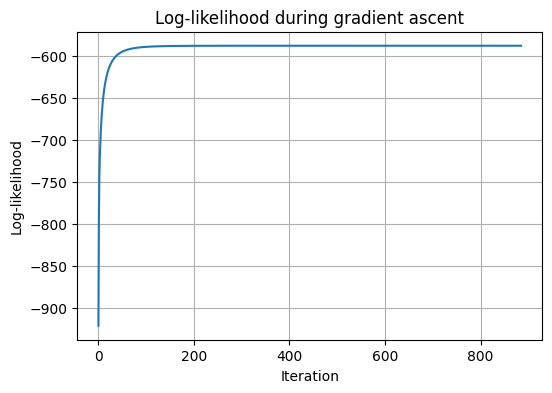

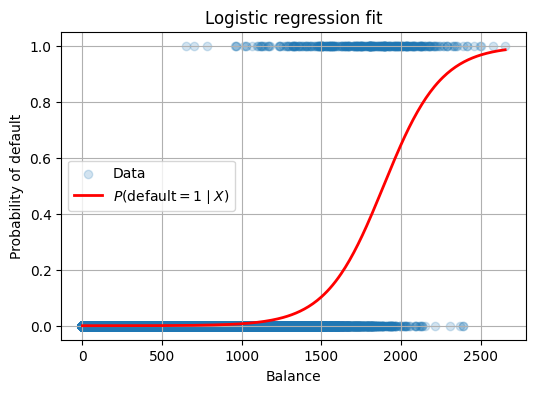


Standard Errors: [0.21795542 0.12587856 0.12710535 0.27549782]
Z-statistics: [-26.7605381   21.38972237   1.19979785  -1.33916912]
P-values: [0.         0.         0.23021786 0.18051562]
Optimization terminated successfully.
         Current function value: 0.083929
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6996
Method:                           MLE   Df Model:                            3
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                  0.4569
Time:                        12:37:33   Log-Likelihood:                -587.50
converged:                       True   LL-Null:                       -1081.8
Covariance Type:            nonrobust   LLR p-value:                5.213e-214
                 coef    std err          z      P>|z|      [0.025      0.975

In [149]:
# Fully working logistic regression from scratch (stable + normalized)
# Single notebook cell

import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data

# -----------------------------
# 1. Load data
# -----------------------------
Default = load_data('Default')

# response
y = (Default['default'] == 'Yes').astype(float).values

# predictors
X_cont = Default[['balance', 'income']].values.astype(float)
X_bin = (Default['student'] == 'Yes').astype(float).values.reshape(-1, 1)

# -----------------------------
# 2. Train / test split
# -----------------------------
np.random.seed(0)
idx = np.random.permutation(len(y))
n_train = int(0.7 * len(y))
train_idx = idx[:n_train]
test_idx  = idx[n_train:]

# -----------------------------
# 3. Standardize continuous features (train statistics only)
# -----------------------------
mu = X_cont[train_idx].mean(axis=0)
sigma = X_cont[train_idx].std(axis=0)

X_cont_scaled = (X_cont - mu) / sigma

# design matrix: intercept + scaled continuous + binary
X = np.hstack([
    np.ones((len(y), 1)),
    X_cont_scaled,
    X_bin
])

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# -----------------------------
# 4. Logistic regression utilities
# -----------------------------
def sigmoid(z):
    z = np.clip(z, -30, 30)   # numerical stability
    return 1 / (1 + np.exp(-z))

def log_likelihood(X, y, beta, eps=1e-9):
    p = sigmoid(X @ beta)
    p = np.clip(p, eps, 1 - eps)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

def gradient_ascent(X, y, lr=1e-3, max_iter=20000, tol=1e-6):
    beta = np.zeros(X.shape[1])
    ll_hist = []

    for i in range(max_iter):
        p = sigmoid(X @ beta)
        grad = X.T @ (y - p)
        beta_new = beta + lr * grad

        ll = log_likelihood(X, y, beta_new)
        ll_hist.append(ll)

        if np.linalg.norm(beta_new - beta) < tol:
            print(f"Converged after {i} iterations")
            break

        beta = beta_new

    return beta, ll_hist

# -----------------------------
# 5. Fit model
# -----------------------------
beta_hat, ll_hist = gradient_ascent(X_train, y_train)

print("Estimated coefficients (scaled model):")
print(f"Intercept: {beta_hat[0]:.4f}")
print(f"Balance  : {beta_hat[1]:.4f}")
print(f"Income   : {beta_hat[2]:.4f}")
print(f"Student  : {beta_hat[3]:.4f}")

# -----------------------------
# 6. Back-transform coefficients to original scale
# -----------------------------
beta_balance = beta_hat[1] / sigma[0]
beta_income  = beta_hat[2] / sigma[1]
beta_intercept = (
    beta_hat[0]
    - beta_hat[1] * mu[0] / sigma[0]
    - beta_hat[2] * mu[1] / sigma[1]
)

print("\nCoefficients on original scale:")
print(f"Intercept: {beta_intercept:.4f}")
print(f"Balance  : {beta_balance:.6f}")
print(f"Income   : {beta_income:.6f}")
print(f"Student  : {beta_hat[3]:.4f}")

# -----------------------------
# 7. Visualizations
# -----------------------------
# log-likelihood
plt.figure(figsize=(6,4))
plt.plot(ll_hist)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood during gradient ascent")
plt.grid(True)
plt.show()

# predicted probabilities vs balance
bal_grid = np.linspace(
    X_cont[:,0].min(), X_cont[:,0].max(), 300
)

bal_grid_scaled = (bal_grid - mu[0]) / sigma[0]
income_mean_scaled = (X_cont[:,1].mean() - mu[1]) / sigma[1]

X_plot = np.column_stack([
    np.ones(len(bal_grid)),
    bal_grid_scaled,
    np.full(len(bal_grid), income_mean_scaled),
    np.zeros(len(bal_grid))  # non-student
])

p_plot = sigmoid(X_plot @ beta_hat)

plt.figure(figsize=(6,4))
plt.scatter(Default['balance'], y, alpha=0.2, label="Data")
plt.plot(bal_grid, p_plot, color="red", linewidth=2,
         label=r"$P(\mathrm{default}=1 \mid X)$")
plt.xlabel("Balance")
plt.ylabel("Probability of default")
plt.title("Logistic regression fit")
plt.legend()
plt.grid(True)
plt.show()

# now calculate the stdandard errors, z-statistics and p-values for beta coefficients

import scipy.stats as stats
def standard_errors(X, y, beta):
    p = sigmoid(X @ beta)
    W = np.diag(p * (1 - p))
    cov_matrix = np.linalg.inv(X.T @ W @ X)
    se = np.sqrt(np.diag(cov_matrix))
    return se
se_beta = standard_errors(X_train, y_train, beta_hat)
z_stats = beta_hat / se_beta
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))
print("\nStandard Errors:", se_beta)
print("Z-statistics:", z_stats)
print("P-values:", p_values)
# now compare it to statsmodels
import statsmodels.api as sm
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()
print(result.summary())

## Multinomial Logistic Regression

### Motivation

Binary logistic regression models the conditional probability
$$
P(Y = 1 \mid X)
$$
for a response variable with two classes.
However, many classification problems involve more than two classes,
$$
Y \in \{1, 2, \dots, K\}, \quad K > 2.
$$
Multinomial logistic regression extends logistic regression to this multiclass setting
while retaining a probabilistic interpretation.

---

## From Binary to Multiclass Logistic Regression

### 1. Binary logistic regression (recap)

For binary classification with classes $\{0,1\}$, logistic regression models the **log-odds**
as a linear function of the predictors:
$$
\log\frac{P(Y=1 \mid X)}{P(Y=0 \mid X)}
=
\beta_0 + \beta^T X.
$$

Applying the inverse-logit (sigmoid) function yields:
$$
P(Y=1 \mid X)
=
\frac{\exp(\beta_0 + \beta^T X)}{1 + \exp(\beta_0 + \beta^T X)}.
$$

---

### 2. Key idea for the multiclass case

For $K$ classes, we want to model:
$$
P(Y = k \mid X), \quad k = 1, \dots, K,
$$
such that:
$$
\sum_{k=1}^K P(Y = k \mid X) = 1,
\quad
P(Y = k \mid X) \ge 0.
$$

The idea is to model **log-odds relative to a reference class**.

---

## Multinomial Logistic Regression Model

### 1. Choosing a reference class

Select one class (usually class $K$) as the **baseline**.
For each remaining class $k = 1, \dots, K-1$, define:
$$
\log\frac{P(Y = k \mid X)}{P(Y = K \mid X)}
=
\beta_{k0} + \beta_k^T X.
$$

Each class gets its own linear predictor.

---

### 2. Softmax formulation

Solving the above system yields the **softmax probabilities**:

For $k = 1, \dots, K-1$:
$$
P(Y = k \mid X)
=
\frac{\exp(\beta_{k0} + \beta_k^T X)}
{1 + \sum_{j=1}^{K-1} \exp(\beta_{j0} + \beta_j^T X)},
$$

and for the reference class:
$$
P(Y = K \mid X)
=
\frac{1}
{1 + \sum_{j=1}^{K-1} \exp(\beta_{j0} + \beta_j^T X)}.
$$

This guarantees that all probabilities are positive and sum to one.

---

## Relationship to Binary Logistic Regression

- If $K = 2$, multinomial logistic regression **reduces exactly** to binary logistic regression.
- The sigmoid function is a special case of the softmax function.
- Logistic regression is therefore a **two-class softmax model**.

---

## Estimation via Maximum Likelihood

Given observations $(x_i, y_i)$, the likelihood is:
$$
L(\{\beta_k\})
=
\prod_{i=1}^n
\prod_{k=1}^K
P(Y = k \mid x_i)^{\mathbb{I}(y_i = k)}.
$$

Taking logs:
$$
\ell(\{\beta_k\})
=
\sum_{i=1}^n
\sum_{k=1}^K
\mathbb{I}(y_i = k)\log P(Y = k \mid x_i).
$$

There is **no closed-form solution**, so parameters are estimated using
iterative optimization (e.g. gradient ascent, Newton–Raphson).

---

## Interpretation of the Coefficients

For class $k$ relative to the reference class $K$:
$$
\beta_{kj}
$$
represents the change in the **log-odds**
$$
\log\frac{P(Y = k \mid X)}{P(Y = K \mid X)}
$$
associated with a one-unit increase in predictor $X_j$,
holding other predictors fixed.

---

## Decision Rule

Prediction is performed by:
$$
\hat y = \arg\max_{k} P(Y = k \mid X).
$$

This is a direct approximation to the Bayes classifier when
$P(Y=k \mid X)$ is correctly specified.

---

## Key Takeaway

> Multinomial logistic regression generalizes logistic regression by
> modeling class probabilities via log-odds relative to a reference class,
> leading to the softmax function.
> It provides a probabilistic, interpretable, and Bayes-consistent
> approach to multiclass classification.


## Note

### Multinomial Logistic Regression – Concrete Example

Assume:
- Number of classes: K = 4
- Number of predictors: p = 3
- Intercept included

Let the feature vector be
$$
x = (1, x_1, x_2, x_3)^\top \in \mathbb{R}^{4}.
$$

---

### 1. Beta matrix with a reference class

Choose class 4 as the reference class:
$$
\beta_4 = (0,0,0,0)^\top.
$$

The coefficient matrix contains one row per *non-reference* class:
$$
B =
\begin{pmatrix}
\beta_{10} & \beta_{11} & \beta_{12} & \beta_{13} \\
\beta_{20} & \beta_{21} & \beta_{22} & \beta_{23} \\
\beta_{30} & \beta_{31} & \beta_{32} & \beta_{33}
\end{pmatrix}
\in \mathbb{R}^{3 \times 4}.
$$

Total number of free parameters:
$$
(K-1)(p+1) = 3 \cdot 4 = 12.
$$

---

### 2. Linear predictors (class scores)

For classes $k = 1,2,3$:
$$
\eta_k(x) = \beta_k^\top x
= \beta_{k0} + \beta_{k1} x_1 + \beta_{k2} x_2 + \beta_{k3} x_3.
$$

For the reference class:
$$
\eta_4(x) = 0.
$$

---

### 3. Softmax probabilities

The class probabilities are obtained by softmax normalization:
$$
P(Y = k \mid x)
=
\frac{\exp(\eta_k(x))}
{1 + \sum_{j=1}^{3} \exp(\eta_j(x))},
\quad k = 1,2,3,
$$

and for the reference class:
$$
P(Y = 4 \mid x)
=
\frac{1}
{1 + \sum_{j=1}^{3} \exp(\eta_j(x))}.
$$

---

### 4. Interpretation

- Each row of $B$ defines a **linear score** for one class relative to class 4.
- The softmax ensures:
  $$
  \sum_{k=1}^{4} P(Y=k \mid x) = 1.
  $$
- Increasing $\eta_k(x)$ increases $P(Y=k \mid x)$ **at the expense of the other classes**.

---
For 4 classes and 3 predictors, multinomial logistic regression uses a $3 \times 4$ coefficient matrix. Each row corresponds to one class-specific linear predictor, and the softmax function converts these scores into valid class probabilities relative to a reference class.


Estimated coefficients (scaled model):
Class 0 coefficients: [-0.40048658 -2.81526726  2.31809425 -4.929987   -4.81931988]
Class 1 coefficients: [ 5.75160904  1.92437328 -0.48842136 -2.21547821 -2.11405696]
Class 2 coefficients: [-5.35112246  0.89089398 -1.82967289  7.14546522  6.93337684]
Test accuracy: 0.956
         Current function value: 0.037561
         Iterations: 35
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  105
Model:                        MNLogit   Df Residuals:                       95
Method:                           MLE   Df Model:                            8
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                  0.9658
Time:                        12:37:36   Log-Likelihood:                -3.9439
converged:                      False   LL-Null:                       -115.16
Covariance Type:            nonrobust   LLR p-value:                 

d:\PythonCode\DL_Stuff\DS.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


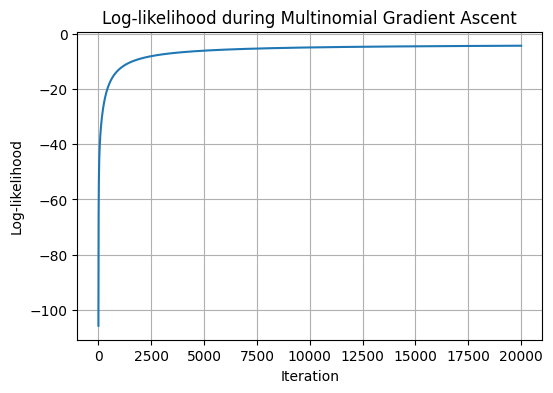

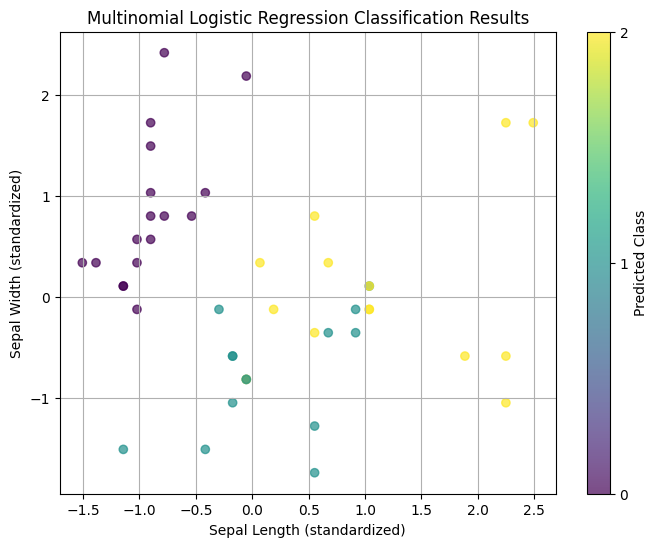


Standard Errors (Multinomial): [[ 9.5394817  21.46323787  7.25706576 26.97627916 23.90865545]
 [ 1.62608571  1.61025849  1.06504032  3.50165031  3.3069816 ]
 [ 3.61347137  1.620409    1.13906892  4.395796    4.20546243]]
Z-statistics (Multinomial): [[-0.04198201 -0.13116694  0.31942583 -0.18275267 -0.20157218]
 [ 3.53708848  1.19507103 -0.45859425 -0.63269545 -0.63927086]
 [-1.48088138  0.54979575 -1.60628814  1.62552248  1.6486598 ]]
P-values (Multinomial): [[9.66513043e-01 8.95643247e-01 7.49403627e-01 8.54992088e-01
  8.40251193e-01]
 [4.04564103e-04 2.32059279e-01 6.46525569e-01 5.26932543e-01
  5.22646744e-01]
 [1.38638186e-01 5.82459475e-01 1.08210616e-01 1.04051278e-01
  9.92173507e-02]]


In [150]:
## Multiple Logistic Regression example

# Get multi class iris dataset see iris csv file
import pandas as pd
iris = pd.read_csv('data/iris.csv')

# Explore the dataset
iris.head()
# sepal length, sepal width, petal length, petal width, species
# We will perform logistic regression to classify the species based on the features

# Prepare the data
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris['species'].values
# Encode the species labels to integers
# 'setosa' -> 0, 'versicolor' -> 1, 'virginica' -> 2
y_encoded = np.array([0 if label == 'setosa' else 1 if label == 'versicolor' else 2 for label in y])

# normalize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std
# Design matrix with intercept
X_design = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])
# Train / test split
np.random.seed(0)
idx = np.random.permutation(len(X_design))
n_train = int(0.7 * len(X_design))
train_idx = idx[:n_train]
test_idx  = idx[n_train:]
X_train, y_train = X_design[train_idx], y_encoded[train_idx]
X_test,  y_test  = X_design[test_idx],  y_encoded[test_idx]

# Fit multinomial logistic regression from scratch
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / exp_z.sum(axis=1, keepdims=True) 

def multinomial_log_likelihood(X, y, beta, eps=1e-9):
    logits = X @ beta.T
    p = softmax(logits)
    p = np.clip(p, eps, 1 - eps)
    ll = 0
    for i in range(len(y)):
        ll += np.log(p[i, y[i]])
    return ll

def multinomial_gradient_ascent(X, y, n_classes, lr=1e-3, max_iter=20000, tol=1e-6):
    beta = np.zeros((n_classes, X.shape[1]))
    ll_hist = []
    for i in range(max_iter):
        logits = X @ beta.T
        p = softmax(logits)
        grad = np.zeros_like(beta)
        for k in range(n_classes):
            indicator = (y == k).astype(float)
            grad[k] = X.T @ (indicator - p[:, k])
        beta_new = beta + lr * grad
        ll = multinomial_log_likelihood(X, y, beta_new)
        ll_hist.append(ll)
        if np.linalg.norm(beta_new - beta) < tol:
            print(f"Converged after {i} iterations")
            break
        beta = beta_new
    return beta, ll_hist

n_classes = 3
beta_hat_multi, ll_hist_multi = multinomial_gradient_ascent(X_train, y_train, n_classes)
print("Estimated coefficients (scaled model):")
for k in range(n_classes):
    print(f"Class {k} coefficients:", beta_hat_multi[k])
    
# Test performance
logits_test = X_test @ beta_hat_multi.T
p_test = softmax(logits_test)
y_pred = np.argmax(p_test, axis=1)
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy:.3f}")

# make a comparison to statsmodels
import statsmodels.api as sm
logit_model_multi = sm.MNLogit(y_train, X_train)
result_multi = logit_model_multi.fit()
print(result_multi.summary())

# make plots of log-likelihood and parameter convergence as before
plt.figure(figsize=(6,4))
plt.plot(ll_hist_multi)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood during Multinomial Gradient Ascent")
plt.grid(True)
plt.show()

# show classification results in a 2D plot using first two features
plt.figure(figsize=(8,6))
plt.scatter(X_test[:,1], X_test[:,2], c=y_pred, cmap='viridis', alpha=0.7)
plt.xlabel("Sepal Length (standardized)")
plt.ylabel("Sepal Width (standardized)")
plt.title("Multinomial Logistic Regression Classification Results")
plt.colorbar(ticks=[0,1,2], label='Predicted Class')
plt.grid(True)
plt.show()

# now show how to calculate standard errors, z-statistics and p-values for multinomial logistic regression
def multinomial_standard_errors(X, y, beta):
    logits = X @ beta.T
    p = softmax(logits)
    n_classes = beta.shape[0]
    se = np.zeros_like(beta)
    for k in range(n_classes):
        W = np.diag(p[:, k] * (1 - p[:, k]))
        cov_matrix = np.linalg.inv(X.T @ W @ X)
        se[k] = np.sqrt(np.diag(cov_matrix))
    return se

se_beta_multi = multinomial_standard_errors(X_train, y_train, beta_hat_multi)
z_stats_multi = beta_hat_multi / se_beta_multi
p_values_multi = 2 * (1 - stats.norm.cdf(np.abs(z_stats_multi)))
print("\nStandard Errors (Multinomial):", se_beta_multi)
print("Z-statistics (Multinomial):", z_stats_multi)
print("P-values (Multinomial):", p_values_multi)

# The optimization did not converge within the maximum number of iterations because the dataset is close to perfectly separable. In such cases, logistic regression coefficients can grow very large, leading to numerical instability. Therefore, regularization techniques or alternative optimization methods may be necessary for better convergence.``



### Why Multinomial Logistic Regression Failed to Converge

Multinomial logistic regression estimates the model parameters by maximizing the likelihood of the observed class labels given the features. When the classes are nearly perfectly separable, the model can assign extremely high probabilities to the correct class by making the linear predictors arbitrarily large.

#### Explanation using the Sigmoid (binary) case

For a single observation $(x_i, y_i)$ with $y_i \in \{0,1\}$, the log-likelihood is

$$
\ell_i(\beta) = y_i \log \sigma(\eta_i) + (1 - y_i) \log \big(1 - \sigma(\eta_i)\big),
$$

where 

$$
\eta_i = \beta_0 + \beta^T x_i, \quad 
\sigma(\eta) = \frac{1}{1 + e^{-\eta}}.
$$

- If $y_i = 1$ and $\eta_i \to +\infty$, then $\sigma(\eta_i) \to 1$ and $\log \sigma(\eta_i) \to 0$.  
- If $y_i = 0$ and $\eta_i \to -\infty$, then $\sigma(\eta_i) \to 0$ and $\log (1-\sigma(\eta_i)) \to 0$.

To maximize the likelihood, the optimizer increases $|\eta_i|$  indefinitely for correctly classified points. Therefore, the log-likelihood grows without bound and the coefficients diverge.

#### Key points

1. **Likelihood behavior:** The log-likelihood is unbounded for nearly perfectly separable data.  
2. **Numerical instability:** Very large coefficients produce large exponentials in the softmax,
   causing overflow and unstable gradient updates.  
3. **Implications:** Coefficients can diverge, standard errors and p-values become unreliable,
   and optimization may not converge.  
4. **Practical solutions:** Use regularization (L1/L2) or alternative optimization methods (e.g., stochastic gradient descent) to stabilize convergence.

**Summary:** Nearly perfect separation makes the likelihood unbounded, causing coefficient estimates to diverge and preventing classical maximum likelihood optimization from converging.


In [151]:
## Adding a regularization term to logistic regression
# Regularized Logistic Regression from scratch 

import numpy as np
import matplotlib.pyplot as plt
# Get multi class iris dataset see iris csv file
import pandas as pd
iris = pd.read_csv('data/iris.csv')

# Explore the dataset
iris.head()
# sepal length, sepal width, petal length, petal width, species
# We will perform logistic regression to classify the species based on the features

# Prepare the data
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris['species'].values
# Encode the species labels to integers
# 'setosa' -> 0, 'versicolor' -> 1, 'virginica' -> 2
y_encoded = np.array([0 if label == 'setosa' else 1 if label == 'versicolor' else 2 for label in y])

# normalize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std
# Design matrix with intercept
X_design = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])
# Train / test split
np.random.seed(0)
idx = np.random.permutation(len(X_design))
n_train = int(0.7 * len(X_design))
train_idx = idx[:n_train]
test_idx  = idx[n_train:]
X_train, y_train = X_design[train_idx], y_encoded[train_idx]
X_test,  y_test  = X_design[test_idx],  y_encoded[test_idx]

# Fit multinomial logistic regression from scratch
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / exp_z.sum(axis=1, keepdims=True) 

def multinomial_log_likelihood(X, y, beta, eps=1e-9):
    logits = X @ beta.T
    p = softmax(logits)
    p = np.clip(p, eps, 1 - eps)
    ll = 0
    for i in range(len(y)):
        ll += np.log(p[i, y[i]])
    return ll

# now add L2 regularization term to the log-likelihood
def multinomial_log_likelihood_reg(X, y, beta, lambda_reg, eps=1e-9):
    logits = X @ beta.T
    p = softmax(logits)
    p = np.clip(p, eps, 1 - eps)
    ll = 0
    for i in range(len(y)):
        ll += np.log(p[i, y[i]])
    # L2 regularization term
    reg_term = - (lambda_reg / 2) * np.sum(beta[:, 1:] ** 2)  # exclude intercept from regularization
    return ll + reg_term
def multinomial_gradient_ascent_reg(X, y, n_classes, lambda_reg, lr=1e-3, max_iter=20000, tol=1e-6):
    beta = np.zeros((n_classes, X.shape[1]))
    ll_hist = []
    for i in range(max_iter):
        logits = X @ beta.T
        p = softmax(logits)
        grad = np.zeros_like(beta)
        for k in range(n_classes):
            indicator = (y == k).astype(float)
            grad[k] = X.T @ (indicator - p[:, k]) - lambda_reg * np.hstack(([0], beta[k, 1:]))  # exclude intercept from regularization
        beta_new = beta + lr * grad
        ll = multinomial_log_likelihood_reg(X, y, beta_new, lambda_reg)
        ll_hist.append(ll)
        if np.linalg.norm(beta_new - beta) < tol:
            print(f"Converged after {i} iterations")
            break
        beta = beta_new
    return beta, ll_hist

n_classes = 3
lambda_reg = 1  # regularization strength
beta_hat_multi_reg, ll_hist_multi_reg = multinomial_gradient_ascent_reg(X_train, y_train, n_classes, lambda_reg)
print("Estimated coefficients with regularization (unscaled model):")
for k in range(n_classes):
    # back-transform coefficients to original scale vectorized
    beta_hat_multi_reg_scaled = beta_hat_multi_reg.copy()
    beta_hat_multi_reg_scaled[:, 1:] = beta_hat_multi_reg[:, 1:] / X_std
    beta_hat_multi_reg_scaled[:, 0] = beta_hat_multi_reg[:, 0] - np.sum(beta_hat_multi_reg[:, 1:] * X_mean / X_std, axis=1)
    print(f"Class {k} coefficients:", beta_hat_multi_reg_scaled[k])
# Test performance
logits_test = X_test @ beta_hat_multi_reg.T
p_test = softmax(logits_test)
y_pred = np.argmax(p_test, axis=1)
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy with regularization: {accuracy:.3f}")
# now compare it to statsmodels with regularization
import statsmodels.api as sm
logit_model_multi_reg = sm.MNLogit(y_train, X_train)
result_multi_reg = logit_model_multi_reg.fit_regularized(penalty='l2', alpha=lambda_reg)
print(result_multi_reg.summary())




Converged after 6865 iterations
Estimated coefficients with regularization (unscaled model):
Class 0 coefficients: [ 6.13072978 -1.2509318   2.37500433 -0.98596327 -2.19046257]
Class 1 coefficients: [ 2.1808409   0.60150337 -0.64073117 -0.1824647  -0.98251161]
Class 2 coefficients: [-8.31157069  0.64942843 -1.73427315  1.16842796  3.17297417]
Test accuracy with regularization: 0.956
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3208189511346039
            Iterations: 87
            Function evaluations: 87
            Gradient evaluations: 87
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  105
Model:                        MNLogit   Df Residuals:                       97
Method:                           MLE   Df Model:                            6
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                  0.8744
Time:    

# Generative Models for Classification

In logistic regression we directly model $Pr(Y=k|X=x)$ using the logistic function. Or speaking differently we model the conditional distribution of Y for given predictors X.  

But we can also phrase the classification in a different way using bayes theorem to flip predictor X and response Y giving $Pr(X=x|Y=k)$ which means what is the probability to observe x if y is from class k or what feature vector do we expect for a given class. 

Why rephrase it and introduce another classification idea?

1. logistic regression tend to be unstable when there is substantial separation between two classes (See Example above!)
2. With small sample sizes n and approximately normal distributed predictors X the approach is more robust
3. This approach can be easily extend to more then two classes

## Idea

We have a function $f_k(X)$ equivalent to $Pr(X=x|Y=k)$ as density function of X coming from k then $f_k$ is large if X is from class k and small if not. Furthermore we have a prior $\pi_k$ propbability that a random observation comes from k. Then we can write the 

$$
P_r(Y=k|X=x) = \frac{\pi_k f_k}{\Sigma \pi_k f_k}
$$

Getting a value for $\pi_k$ is rather straight forward using the frequency of occurence per class in the training dataset. More complicated is to find the function $f_k$. here we will discuss several methods

## Linear Discriminative analysis with p=1 (LDA)
Lets start with a classification setting with a single predictor X.

We look now for a function $f_k$ in order to estimate $P_r$. 

We can assume that $f_k$ is from a normal distribution following the gaussian distribution function. Caution we assume here the underlying distribution of X for class k and thus only approximate $f_k$!

$$
f_k(x) = \frac{1}{\sqrt{2\pi\sigma_k}} exp (-\frac{1}{2\sigma_k^2}(x-\mu_k)^2)
$$

where $\sigma_k$ and $\mu_k$ are the standard deviation and mean of x for class k. For simplicity in LDA we assume that $\sigma$ is shared between the classes and the same.

Then we can calculate $f_k$ and $P_r$ and make predictions. Predictions are made based on the bayes decision boundry which separates the classes from each other.

To start making predictions we need to estimate first $\mu_k$ and $\sigma$ from the training dataset using

$$
\mu_k = \frac{1}{n_k} \Sigma x_i|k
$$

and

$$
\hat \sigma^2 = \frac{1}{n-K} \Sigma_k \Sigma_{y_i=k} (x_i-\mu_k)^2
$$

For predictions we can then calculate 

$$

\delta_k(x) = x \frac{\mu_k}{\sigma_2} - \frac{\mu_k^2}{2\sigma_2} + log(\pi_k)
$$

and see where $\delta_k(x)$ is biggest. The decision boundry is then given where two $\delta_k(x)$ have the same size. 


Class priors: [0.5 0.5]
Class means: [2.05980802 7.08201297]
Shared variance: 1.0537183913147334


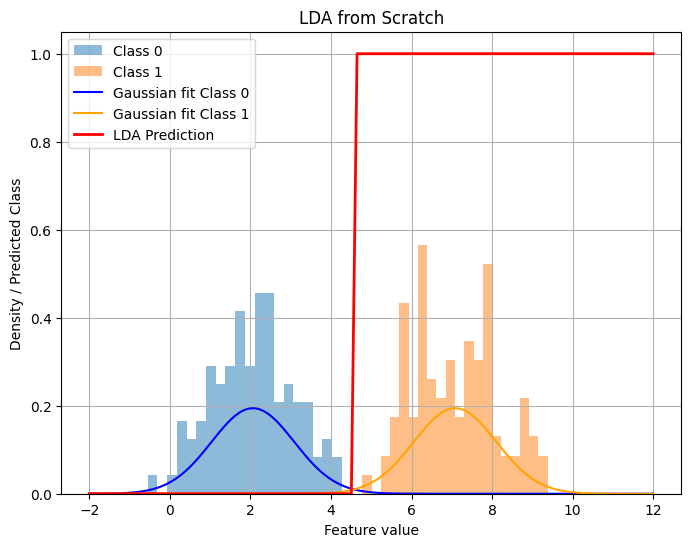

In [152]:
# LDA from scratch 
import numpy as np
import matplotlib.pyplot as plt

# generate synthetic data for two classes
np.random.seed(0)
n_samples = 100
mu1 = 2
sigma1 = 1
mu2 = 7
sigma2 = 1

X1 = np.random.normal(mu1, sigma1, n_samples)
X2 = np.random.normal(mu2, sigma2, n_samples)
y1 = np.zeros(n_samples)
y2 = np.ones(n_samples)
X = np.hstack([X1, X2])
y = np.hstack([y1, y2])

# fit LDA model


def fit_lda(X, y):
    classes = 2
    n = len(y)
    pi1 = np.sum(y == 0) / n
    pi2 = np.sum(y == 1) / n
    pik = np.array([pi1, pi2])
    mu1 = np.mean(X[y == 0])
    mu2 = np.mean(X[y == 1])
    mu = np.array([mu1, mu2])
    sigma_squared = 1 / (n - classes) * (
        np.sum((X[y == 0] - mu1) ** 2) + np.sum((X[y == 1] - mu2) ** 2)
    )
    
    return pik, mu, sigma_squared

pik, mu, sigma_squared = fit_lda(X, y)
print("Class priors:", pik)
print("Class means:", mu)
print("Shared variance:", sigma_squared)

# predict using LDA model
def predict_lda(X, pik, mu, sigma_squared):
    logits = np.zeros((len(X), 2))
    for k in range(2):
        logits[:, k] = (
            np.log(pik[k])
            - 0.5 * np.log(2 * np.pi * sigma_squared)
            - (X - mu[k]) ** 2 / (2 * sigma_squared)
        )
    return np.argmax(logits, axis=1)

# generate test data
X_test = np.linspace(-2, 12, 100)
y_pred = predict_lda(X_test, pik, mu, sigma_squared)

# plot results
plt.figure(figsize=(8, 6))
# plot two classes as histograms with gaussian fits
plt.hist(X1, bins=20, alpha=0.5, label='Class 0', density=True)
plt.hist(X2, bins=20, alpha=0.5, label='Class 1', density=True)
# plot gaussian fits
x_range = np.linspace(-2, 12, 300)
pdf1 = (1 / np.sqrt(2 * np.pi * sigma_squared)) * np.exp(-0.5 * ((x_range - mu[0]) ** 2) / sigma_squared)
pdf2 = (1 / np.sqrt(2 * np.pi * sigma_squared)) * np.exp(-0.5 * ((x_range - mu[1]) ** 2) / sigma_squared)
plt.plot(x_range, pdf1 * pik[0], color='blue', label='Gaussian fit Class 0')
plt.plot(x_range, pdf2 * pik[1], color='orange', label='Gaussian fit Class 1')
# plot decision boundary
plt.plot(X_test, y_pred, color='red', linewidth=2, label='LDA Prediction')
plt.xlabel('Feature value')
plt.ylabel('Density / Predicted Class')
plt.title('LDA from Scratch')
plt.legend()
plt.grid()
plt.show()





### Linear Discriminant Analysis (LDA) – Generative Perspective

Linear Discriminant Analysis (LDA) is a **generative classification method**.
Unlike discriminative models, it does not model the decision boundary directly.
Instead, it models how the data are generated by learning the **joint distribution**
of features and labels:

$$
P(X, Y) = P(X \mid Y)\,P(Y).
$$

---

### Model assumptions

For each class \( k \):

$$
X \mid Y=k \sim \mathcal{N}(\mu_k, \Sigma),
\quad
P(Y=k) = \pi_k.
$$

All classes share the same covariance matrix \( \Sigma \), which leads to a **linear**
decision boundary.

---

### Parameter estimation

The model parameters are estimated via maximum likelihood:

- Class priors:
$$
\pi_k = \frac{n_k}{n}
$$

- Class means:
$$
\mu_k = \frac{1}{n_k} \sum_{i:y_i=k} x_i
$$

- Shared covariance:
$$
\Sigma = \frac{1}{n-K} \sum_{k=1}^{K} \sum_{i:y_i=k} (x_i - \mu_k)(x_i - \mu_k)^T
$$

---

### Classification via Bayes’ rule

Given the generative model, posterior class probabilities are obtained using Bayes’ rule:

$$
P(Y=k \mid X=x)
=
\frac{P(X=x \mid Y=k)\,P(Y=k)}{P(X=x)}.
$$

The prediction rule is:

$$
\hat y = \arg\max_k P(X=x \mid Y=k)\,P(Y=k).
$$

---

### Why LDA is called *generative*

- LDA explicitly models how each class generates data via \( P(X \mid Y) \).
- Together with class priors, this defines a full probabilistic data-generating process.
- New samples can be generated from the learned Gaussian class distributions.

---

### Generative vs. discriminative

- **Generative methods (LDA, QDA, Naive Bayes):**
  - Model \( P(X \mid Y) \) and \( P(Y) \)
  - Typically stable even under class separation
- **Discriminative methods (Logistic Regression, SVM):**
  - Model \( P(Y \mid X) \) directly
  - Focus solely on the decision boundary

---

**Key takeaway:**  
> LDA is a generative method because it models the data-generation process
> \( P(X,Y) \), and classification follows from Bayes’ rule rather than direct
> boundary fitting.


## Linear Discriminant Analysis for $$p > 1$$

So far, we considered LDA with a single predictor $$X_1$$.
We now extend the model to **multiple predictors**
$$
X \in \mathbb{R}^p,
$$
allowing classification with multiple features and
application to the Iris (petal) dataset.

The key difference compared to the $$p = 1$$ case is that each class is now
modeled by a **multivariate Gaussian distribution**.

---

### Class-conditional density

For each class $$k$$:

$$
X \mid Y = k \sim \mathcal{N}(\mu_k, \Sigma),
$$

where:
- $$\mu_k \in \mathbb{R}^p$$ is the class mean vector,
- $$\Sigma \in \mathbb{R}^{p \times p}$$ is the **shared covariance matrix**.

The class-conditional density becomes:

$$
f_k(x)
=
\frac{1}{(2\pi)^{p/2} |\Sigma|^{1/2}}
\exp\!\left(
-\frac{1}{2}(x-\mu_k)^T \Sigma^{-1} (x-\mu_k)
\right).
$$

---

### Discriminant function

Taking the logarithm and removing terms independent of $$k$$ yields the
linear discriminant function:

$$
\delta_k(x)
=
x^T \Sigma^{-1} \mu_k
-
\frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k
+
\log \pi_k.
$$

---

### Decision rule

Classification is performed by:

$$
\hat y = \arg\max_k \delta_k(x).
$$

---

**Key takeaway:**  
> For $$p>1$$, LDA models each class with a multivariate Gaussian distribution
> sharing a common covariance matrix, resulting in linear decision boundaries
> in the feature space.


Class priors: [0.33333333 0.33333333 0.33333333]
Class means: [[5.006 3.418 1.464 0.244]
 [5.936 2.77  4.26  1.326]
 [6.588 2.974 5.552 2.026]]
Shared variance: 0.6080734693877551
LDA classification accuracy on iris dataset: 0.927


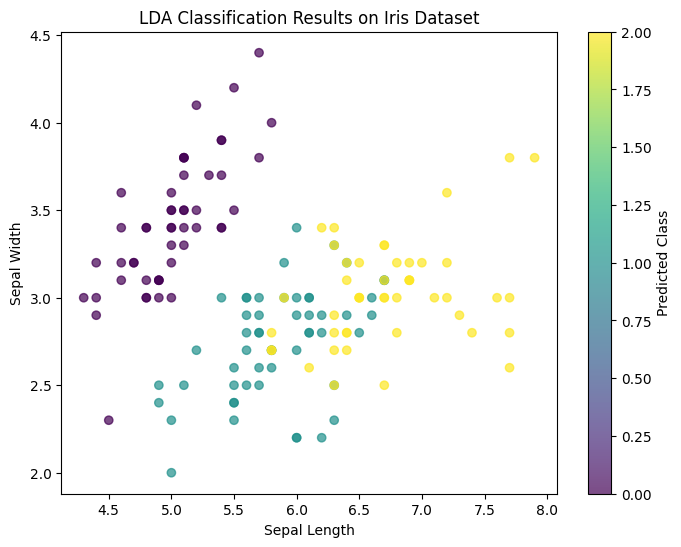

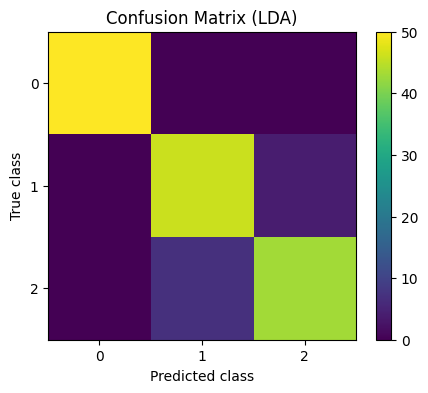

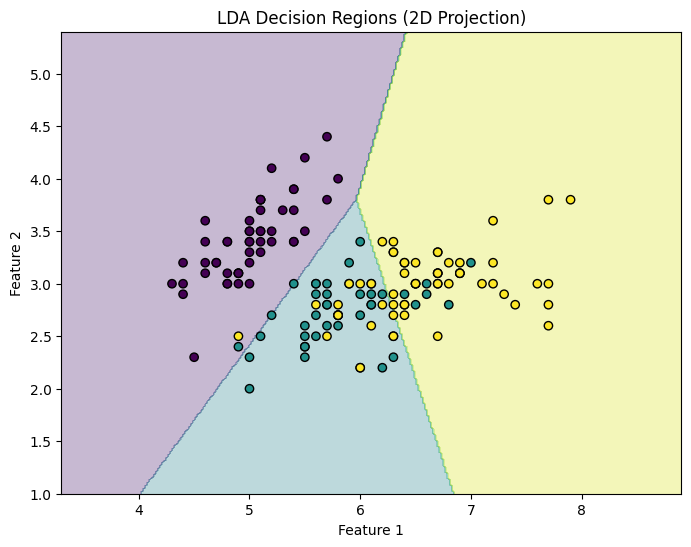

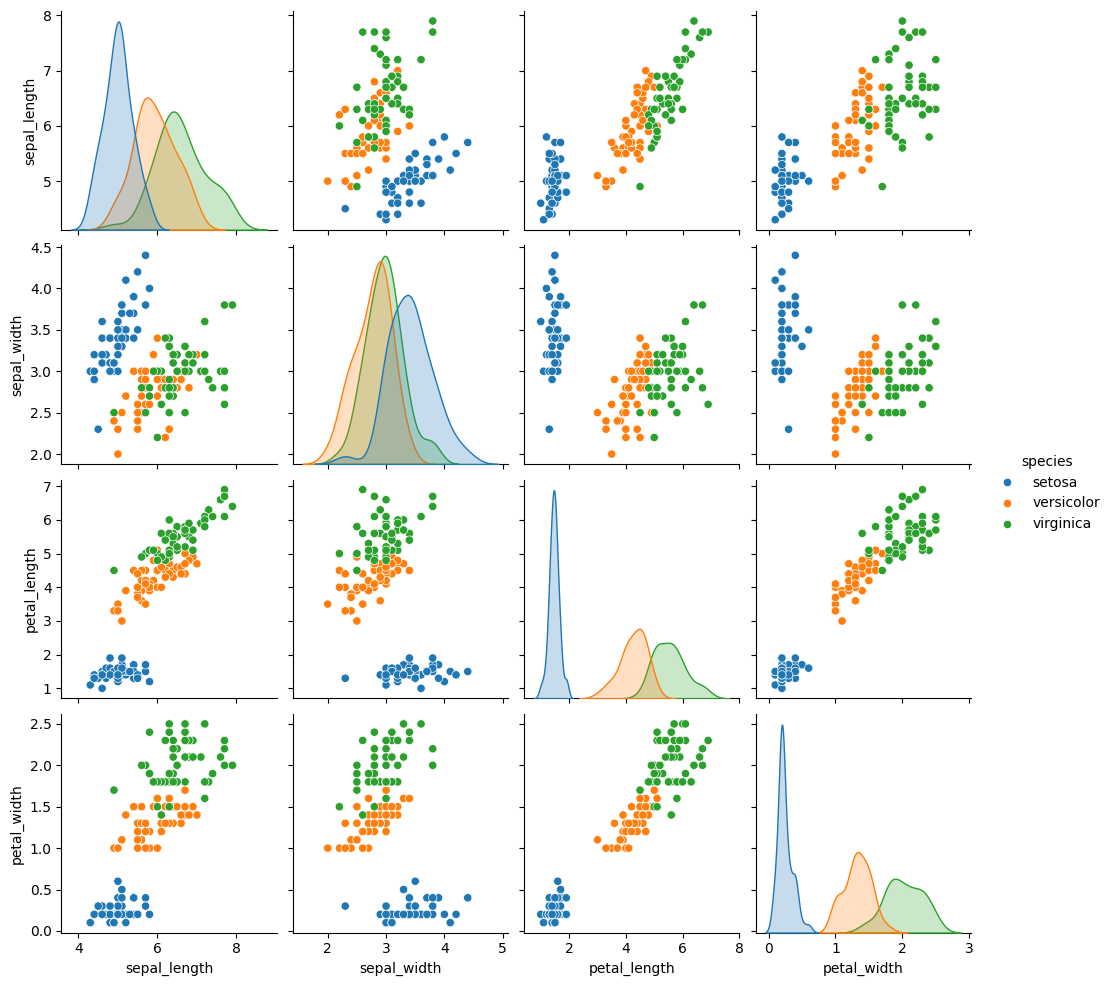

In [153]:
# LDA fitting to iris dataset
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Load iris dataset
iris = pd.read_csv('data/iris.csv')
# Prepare data
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris['species'].values
# Encode species labels to integers
y_encoded = np.array([0 if label == 'setosa' else 1 if label == 'versicolor' else 2 for label in y])

# Fit LDA model
def fit_lda_multiclass(X, y):
    classes = np.unique(y)
    n_classes = len(classes)
    n_samples, n_features = X.shape
    pik = np.array([np.sum(y == k) / n_samples for k in classes])
    mu = np.array([X[y == k].mean(axis=0) for k in classes])
    sigma_squared = 0
    for k in classes:
        sigma_squared += np.sum((X[y == k] - mu[k]) ** 2)
    sigma_squared /= (n_samples - n_classes)
    return pik, mu, sigma_squared

pik, mu, sigma_squared = fit_lda_multiclass(X, y_encoded)
print("Class priors:", pik)
print("Class means:", mu)
print("Shared variance:", sigma_squared)

# Predict using LDA model
def predict_lda_multiclass(X, pik, mu, sigma_squared):
    n_samples = X.shape[0]
    n_classes = len(pik)
    logits = np.zeros((n_samples, n_classes))
    for k in range(n_classes):
        logits[:, k] = (
            np.log(pik[k])
            - 0.5 * np.log(2 * np.pi * sigma_squared)
            - np.sum((X - mu[k]) ** 2, axis=1) / (2 * sigma_squared)
        )
    return np.argmax(logits, axis=1)

y_pred = predict_lda_multiclass(X, pik, mu, sigma_squared)
accuracy = np.mean(y_pred == y_encoded)
print(f"LDA classification accuracy on iris dataset: {accuracy:.3f}")
# Visualize LDA results using first two features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('LDA Classification Results on Iris Dataset')
plt.colorbar(scatter, label='Predicted Class')
plt.show()



cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix (LDA)")
plt.colorbar()
plt.xticks([0,1,2])
plt.yticks([0,1,2])
plt.show()

# use two features only for visualization
X2 = X[:, :2]

# refit LDA on 2 features
pik2, mu2, sigma2 = fit_lda_multiclass(X2, y_encoded)

xx, yy = np.meshgrid(
    np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
    np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_lda_multiclass(grid, pik2, mu2, sigma2)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:,0], X2[:,1], c=y_encoded, edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("LDA Decision Regions (2D Projection)")
plt.show()



import seaborn as sns
sns.pairplot(iris, hue="species")
plt.show()



# Observations
1. LDA runs ways faster then itterative logistic regression due to closed form parameter estimation  mu sigma and pi
2. Decision boundries are modeled based on gaussian distributions --> numerical more stable even in well separable classes
3. LDA operates only good if model assumptions are met (Gaussian Distributions, Classes share a common covariance, low dimensional dataset)



## Effect of the Decision Boundary Threshold, ROC, and True/False Positives

So far, classification with LDA was performed using the **default decision rule**:
assign an observation to the class with the largest posterior probability.
For a binary problem, this is equivalent to using a **decision threshold of 0.5** on
$$
P(Y=1 \mid X).
$$
This choice minimizes the **overall misclassification rate**, assuming equal costs for all errors.

---

### Confusion Matrix and Error Types

The performance of a classifier can be summarized using a **confusion matrix**:

|                | Predicted Positive | Predicted Negative |
|----------------|--------------------|--------------------|
| **Actual Positive** | True Positive TP  | False Negative FN |
| **Actual Negative** | False Positive FP | True Negative TN  |

- **TP:** correctly detected positive cases  
- **TN:** correctly detected negative cases  
- **FP:** negative cases incorrectly labeled as positive  
- **FN:** positive cases incorrectly labeled as negative  

Different applications assign different importance to these error types.

---

### Decision Threshold Trade-off

By changing the decision threshold $\tau$ in
$$
\hat y =
\begin{cases}
1 & \text{if } P(Y=1 \mid X) \ge \tau \\
0 & \text{otherwise},
\end{cases}
$$
we can control the trade-off between:
- **True Positive Rate (TPR / Sensitivity):**
$$
TPR = \frac{TP}{TP + FN}
$$
- **False Positive Rate (FPR):**
$$
FPR = \frac{FP}{FP + TN}
$$

Lowering $\tau$ increases TPR but also increases FPR.
Raising $\tau$ decreases FPR but risks more false negatives.

---

### ROC Curve

The **Receiver Operating Characteristic (ROC) curve** plots:

$$
TPR \quad \text{vs.} \quad FPR
$$

for all possible thresholds $\tau \in [0,1]$.

- A curve closer to the **top-left corner** indicates a better classifier.
- The diagonal line corresponds to random guessing.
- The **Area Under the Curve (AUC)** summarizes performance independently of a specific threshold.

---

### Why Different Thresholds Make Sense

In many real-world problems, minimizing the overall error rate is **not optimal**:

- **Spam filtering:**  
  A legitimate email classified as spam (FP) is often less harmful than letting phishing or malware emails through (FN).

- **Fraud detection:**  
  Blocking a legitimate transaction (FP) is inconvenient,
  but failing to detect fraud (FN) can cause severe financial damage.

In such cases, the decision threshold is deliberately shifted away from 0.5 to reflect asymmetric costs of errors.

---

**Key takeaway:**  
> The default LDA decision boundary minimizes global error under equal costs,
> but practical applications often require adjusting the threshold and evaluating
> performance using confusion matrices and ROC curves.


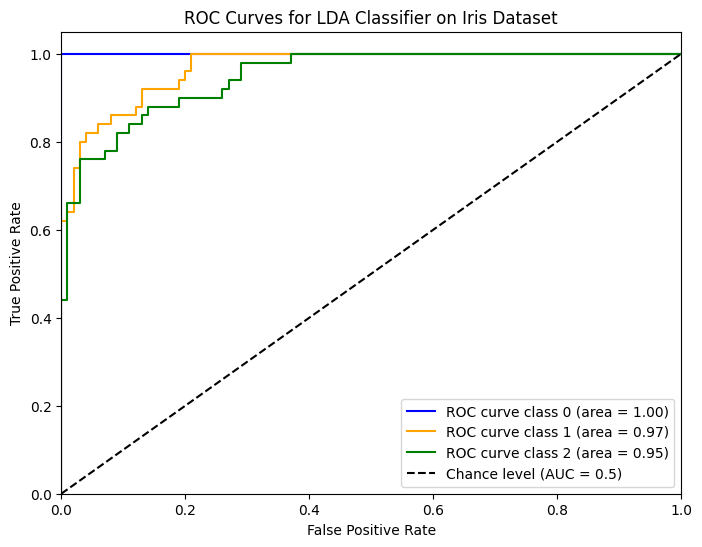

In [154]:
# Plot the ROC curve for the iris dataset using LDA classifier
from sklearn.metrics import roc_curve, auc
y_score = np.zeros((len(y_encoded), 3))
for k in range(3):
    logits = (
        np.log(pik[k])
        - 0.5 * np.log(2 * np.pi * sigma_squared)
        - np.sum((X - mu[k]) ** 2, axis=1) / (2 * sigma_squared)
    )
    y_score[:, k] = logits
fpr = dict()
tpr = dict()
roc_auc = dict()
for k in range(3):
    fpr[k], tpr[k], _ = roc_curve((y_encoded == k).astype(int), y_score[:, k])
    roc_auc[k] = auc(fpr[k], tpr[k])    
plt.figure(figsize=(8,6))
colors = ['blue', 'orange', 'green']
for k, color in zip(range(3), colors):
    plt.plot(fpr[k], tpr[k], color=color,
             label=f'ROC curve class {k} (area = {roc_auc[k]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for LDA Classifier on Iris Dataset")
plt.legend(loc="lower right")
plt.show()


# Quadratic Discriminant Analysis (QDA)

In LDA we model decision boundaries as **linear**, because the class-conditional distributions are **multivariate Gaussians with a shared covariance matrix** $\Sigma$. The decision boundary is determined by a single linear parameter (e.g., threshold 0.5) that minimizes the misclassification rate.

---

### Main Difference between LDA and QDA

In **QDA**, each class has its **own covariance matrix** $\Sigma_k$.  
The Bayes classifier assigns an observation $x$ to the class with the highest posterior probability:

$$
\hat y = \arg\max_k \delta_k(x),
$$

where the **quadratic discriminant function** is:

$$
\delta_k(x) = -\frac{1}{2} \log|\Sigma_k| - \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \log \pi_k.
$$

---

### Implications

- The decision boundaries are now **quadratic**, not linear.
- This allows the classifier to **adapt to differing class covariances**, capturing more complex separation surfaces.
- QDA reduces to LDA when all $\Sigma_k$ are equal.

---

**Key takeaway:**  
> QDA generalizes LDA by allowing class-specific covariances, resulting in quadratic decision boundaries that can better model  data with non common covariance between the predictors X.

LDA Test Accuracy: 0.978
QDA Test Accuracy: 0.978


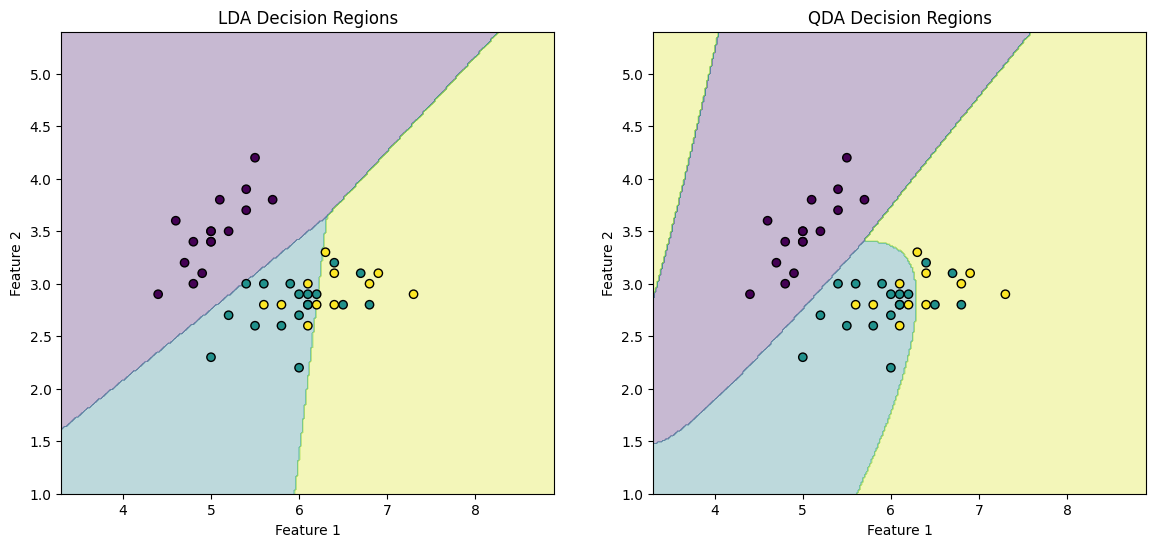

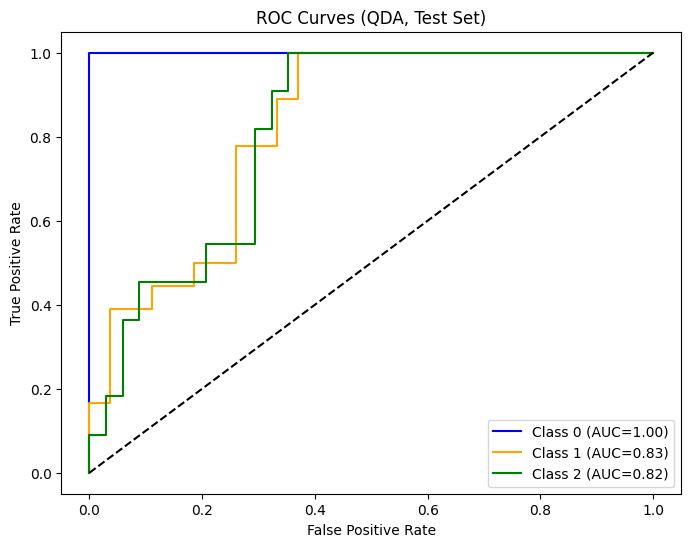

In [155]:
# LDA vs QDA on Iris Dataset with Train/Test Split and Decision Boundaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# Load dataset
iris = pd.read_csv('data/iris.csv')
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris['species'].values
y_encoded = np.array([0 if label=='setosa' else 1 if label=='versicolor' else 2 for label in y])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=0)

# ----------------------------
# LDA Functions
# ----------------------------
def fit_lda_multiclass(X, y):
    classes = np.unique(y)
    n_classes = len(classes)
    n_samples, n_features = X.shape
    pik = np.array([np.sum(y==k)/n_samples for k in classes])
    mu = np.array([X[y==k].mean(axis=0) for k in classes])
    # Shared covariance
    sigma = np.zeros((n_features, n_features))
    for k in classes:
        sigma += (X[y==k]-mu[k]).T @ (X[y==k]-mu[k])
    sigma /= (n_samples - n_classes)
    return pik, mu, sigma

def predict_lda_multiclass(X, pik, mu, sigma):
    sigma_inv = np.linalg.inv(sigma)
    n_samples = X.shape[0]
    n_classes = len(pik)
    logits = np.zeros((n_samples, n_classes))
    for k in range(n_classes):
        diff = X - mu[k]
        logits[:, k] = np.log(pik[k]) - 0.5 * np.sum(diff @ sigma_inv * diff, axis=1)
    return np.argmax(logits, axis=1)

# Fit and predict LDA
pik_lda, mu_lda, sigma_lda = fit_lda_multiclass(X_train, y_train)
y_pred_lda = predict_lda_multiclass(X_test, pik_lda, mu_lda, sigma_lda)
accuracy_lda = np.mean(y_pred_lda == y_test)
print(f"LDA Test Accuracy: {accuracy_lda:.3f}")

# ----------------------------
# QDA Functions
# ----------------------------
def fit_qda_multiclass(X, y):
    classes = np.unique(y)
    n_classes = len(classes)
    pik = np.array([np.sum(y==k)/len(y) for k in classes])
    mu = np.array([X[y==k].mean(axis=0) for k in classes])
    sigma = [np.cov(X[y==k], rowvar=False) for k in classes]
    return pik, mu, sigma

def predict_qda_multiclass(X, pik, mu, sigma):
    n_samples = X.shape[0]
    n_classes = len(pik)
    logits = np.zeros((n_samples, n_classes))
    for k in range(n_classes):
        sigma_inv = np.linalg.inv(sigma[k])
        det_sigma = np.linalg.det(sigma[k])
        diff = X - mu[k]
        logits[:, k] = np.log(pik[k]) - 0.5*np.log(det_sigma) - 0.5*np.sum(diff @ sigma_inv * diff, axis=1)
    return np.argmax(logits, axis=1)

# Fit and predict QDA
pik_qda, mu_qda, sigma_qda = fit_qda_multiclass(X_train, y_train)
y_pred_qda = predict_qda_multiclass(X_test, pik_qda, mu_qda, sigma_qda)
accuracy_qda = np.mean(y_pred_qda == y_test)
print(f"QDA Test Accuracy: {accuracy_qda:.3f}")

# ----------------------------
# Side-by-side Decision Boundaries (using first two features)
# ----------------------------
X_train2 = X_train[:, :2]
X_test2 = X_test[:, :2]

# Refit LDA/QDA on first two features
pik_lda2, mu_lda2, sigma_lda2 = fit_lda_multiclass(X_train2, y_train)
pik_qda2, mu_qda2, sigma_qda2 = fit_qda_multiclass(X_train2, y_train)

# Meshgrid for plotting
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lda = predict_lda_multiclass(grid, pik_lda2, mu_lda2, sigma_lda2).reshape(xx.shape)
Z_qda = predict_qda_multiclass(grid, pik_qda2, mu_qda2, sigma_qda2).reshape(xx.shape)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z_lda, alpha=0.3)
plt.scatter(X_test2[:,0], X_test2[:,1], c=y_test, edgecolor='k')
plt.title("LDA Decision Regions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1,2,2)
plt.contourf(xx, yy, Z_qda, alpha=0.3)
plt.scatter(X_test2[:,0], X_test2[:,1], c=y_test, edgecolor='k')
plt.title("QDA Decision Regions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ----------------------------
# ROC curves for each class (QDA example)
# ----------------------------
y_score_qda = np.zeros((len(y_test), 3))
for k in range(3):
    sigma_inv = np.linalg.inv(sigma_qda[k][:2,:2])  # first two features for visualization
    det_sigma = np.linalg.det(sigma_qda[k][:2,:2])
    diff = X_test2 - mu_qda[k][:2]
    y_score_qda[:,k] = np.log(pik_qda[k]) - 0.5*np.log(det_sigma) - 0.5*np.sum(diff @ sigma_inv * diff, axis=1)

fpr, tpr, roc_auc = dict(), dict(), dict()
colors = ['blue', 'orange', 'green']
plt.figure(figsize=(8,6))
for k, color in zip(range(3), colors):
    fpr[k], tpr[k], _ = roc_curve((y_test == k).astype(int), y_score_qda[:,k])
    roc_auc[k] = auc(fpr[k], tpr[k])
    plt.plot(fpr[k], tpr[k], color=color, label=f'Class {k} (AUC={roc_auc[k]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (QDA, Test Set)")
plt.legend()
plt.show()


## Why not always choose QDA over LDA ?

- The main reason is the number of parameters to predict and thus the introduced flexibility of QDA over LDA. in QDA we estimate for each class a full rank $\Sigma_k$ while we have a shared $\Sigma$ in LDA
- If we have only a few train samples LDA can be more robust then QDA as we need to fit less parameters
- If the predictors show that they do not share a big correlation LDA is off and suffer from high bias



## Naive Bayes Classifier

The **Naive Bayes classifier** is a simple yet powerful generative classification method based on Bayes theorem. It assumes that the features are **conditionally independent** given the class label. This assumption is often not strictly true in practice, but the method still performs well in many applications.

---

### Bayes' Theorem for Classification

Given a feature vector $X = (X_1, X_2, \dots, X_p)$ and class label $Y$, Bayes' theorem gives:

$$
P(Y = k \mid X) = \frac{P(X \mid Y = k) \, P(Y = k)}{P(X)}
$$

The classifier assigns each observation to the class with the **highest posterior probability**.

---

### Naive Independence Assumption

Naive Bayes assumes that the features are independent given the class:

$$
P(X \mid Y = k) = \prod_{j=1}^{p} P(X_j \mid Y = k)
$$

This greatly simplifies the estimation of $P(X \mid Y = k)$, especially in high dimensions.

---

### Types of Naive Bayes

- **Gaussian Naive Bayes:** For continuous features, assumes each feature is normally distributed within each class.
- **Multinomial Naive Bayes:** For count data (e.g., word counts in text classification).
- **Bernoulli Naive Bayes:** For binary features.

---

### Training and Prediction

1. **Estimate class priors:**  

$$
\pi_k = P(Y = k)
$$

from class frequencies in the training data.

2. **Estimate feature distributions:**  
   For each class $k$ and feature $j$, estimate the parameters of $P(X_j \mid Y = k)$.

3. **Prediction:**  
   For a new observation $x$, compute the posterior for each class and assign the class with the highest value.

---

### Comparison to Logistic Regression, LDA, and QDA

- **Logistic Regression**: discriminative model, directly models $P(Y \mid X)$; captures feature interactions but requires more data; does not assume feature independence.
- **LDA**: generative model; assumes multivariate normal features with shared covariance; models correlations; linear decision boundaries.
- **QDA**: generative; each class has its own covariance; quadratic decision boundaries; more flexible but needs more data.
- **Naive Bayes**: generative; assumes conditional independence; extremely fast and simple; may lose accuracy if features are correlated; often works surprisingly well in high-dimensional or sparse data.

---

### Advantages and Limitations

**Advantages:**
- Very fast to train and predict.
- Works well with high-dimensional data.
- Robust to irrelevant features.

**Limitations:**
- Independence assumption is often violated.
- Feature distributions must be well modeled for good performance.

---

**Key Takeaway:**  

> Naive Bayes is a fast, interpretable, and effective classifier leveraging Bayes' theorem with a strong independence assumption. It is simpler and more robust to small sample sizes than LDA, QDA, or logistic regression, but may be less accurate if feature correlations are strong. LDA and QDA model feature correlations, while logistic regression is a flexible discriminative alternative.


Class priors: [0.32380952 0.3047619  0.37142857]
Class means: [[4.99411765 3.38235294 1.45294118 0.22941176]
 [5.921875   2.75625    4.196875   1.30625   ]
 [6.65384615 2.98717949 5.5974359  2.03076923]]
Class variances: [[0.12584775 0.15321799 0.02013841 0.00913495]
 [0.28108398 0.11558594 0.23405273 0.04183594]
 [0.42607495 0.12009204 0.31409599 0.06725838]]
Gaussian Naive Bayes Test Accuracy: 1.000


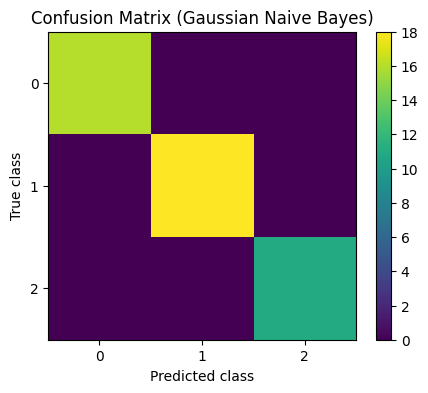

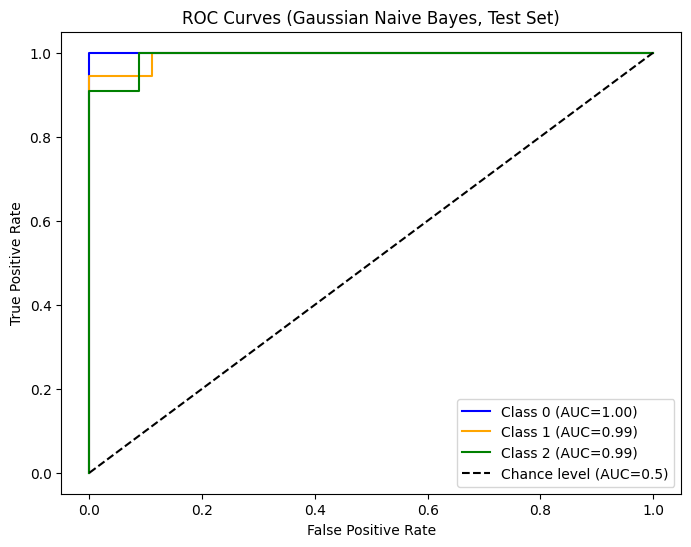

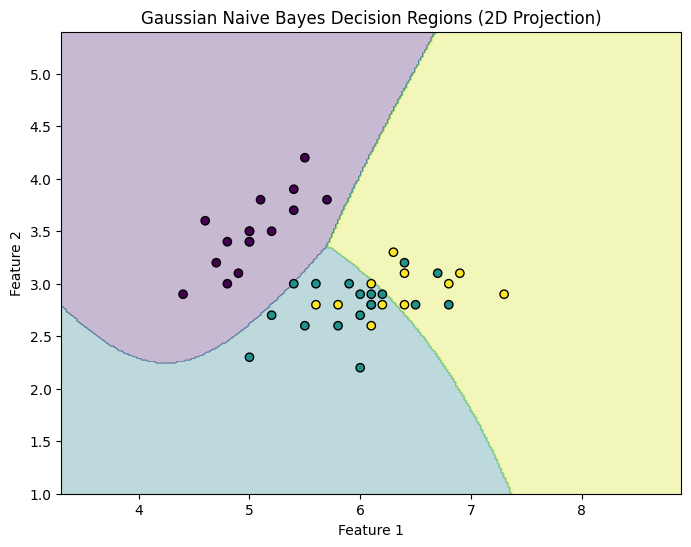

In [156]:
# Iris dataset naive bayes classifier from scratch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
# Load iris dataset
iris = pd.read_csv('data/iris.csv')
# Prepare data
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris['species'].values
# Encode species labels to integers
y_encoded = np.array([0 if label=='setosa' else 1 if label=='versicolor' else 2 for label in y])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=0)

# Fit Gaussian Naive Bayes model
def fit_gnb(X, y):
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]
    pik = np.array([np.sum(y==k)/len(y) for k in classes])
    mu = np.array([X[y==k].mean(axis=0) for k in classes])
    sigma = np.array([X[y==k].var(axis=0) for k in classes])  # variance per feature
    return pik, mu, sigma

pik_gnb, mu_gnb, sigma_gnb = fit_gnb(X_train, y_train) 
print("Class priors:", pik_gnb)
print("Class means:", mu_gnb)
print("Class variances:", sigma_gnb)

# Predict using Gaussian Naive Bayes model
def predict_gnb(X, pik, mu, sigma):
    n_samples = X.shape[0]
    n_classes = len(pik)
    logits = np.zeros((n_samples, n_classes))
    for k in range(n_classes):
        coeff = -0.5 * np.sum(np.log(2 * np.pi * sigma[k]))
        exponent = -0.5 * np.sum(((X - mu[k]) ** 2) / sigma[k], axis=1)
        logits[:, k] = np.log(pik[k]) + coeff + exponent
    return np.argmax(logits, axis=1)

y_pred_gnb = predict_gnb(X_test, pik_gnb, mu_gnb, sigma_gnb)
accuracy_gnb = np.mean(y_pred_gnb == y_test)
print(f"Gaussian Naive Bayes Test Accuracy: {accuracy_gnb:.3f}")

# Confusion matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(5,4))
plt.imshow(cm_gnb)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix (Gaussian Naive Bayes)")
plt.colorbar()
plt.xticks([0,1,2])
plt.yticks([0,1,2])
plt.show()

# ROC curves for each class
y_score_gnb = np.zeros((len(y_test), 3))
for k in range(3):
    coeff = -0.5 * np.sum(np.log(2 * np.pi * sigma_gnb[k]))
    exponent = -0.5 * np.sum(((X_test - mu_gnb[k]) ** 2) / sigma_gnb[k], axis=1)
    y_score_gnb[:,k] = np.log(pik_gnb[k]) + coeff + exponent
fpr, tpr, roc_auc = dict(), dict(), dict()
colors = ['blue', 'orange', 'green']
plt.figure(figsize=(8,6))
for k, color in zip(range(3), colors):
    fpr[k], tpr[k], _ = roc_curve((y_test == k).astype(int), y_score_gnb[:,k])
    roc_auc[k] = auc(fpr[k], tpr[k])
    plt.plot(fpr[k], tpr[k], color=color, label=f'Class {k} (AUC={roc_auc[k]:.2f})')
plt.plot([0,1], [0,1], 'k--', label='Chance level (AUC=0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Gaussian Naive Bayes, Test Set)")
plt.legend()
plt.show()

# Lets visualize decision boundaries using first two features
X_train2 = X_train[:, :2]
X_test2 = X_test[:, :2]
pik_gnb2, mu_gnb2, sigma_gnb2 = fit_gnb(X_train2, y_train)
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_gnb = predict_gnb(grid, pik_gnb2, mu_gnb2, sigma_gnb2).reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z_gnb, alpha=0.3)
plt.scatter(X_test2[:,0], X_test2[:,1], c=y_test, edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Gaussian Naive Bayes Decision Regions (2D Projection)")
plt.show()



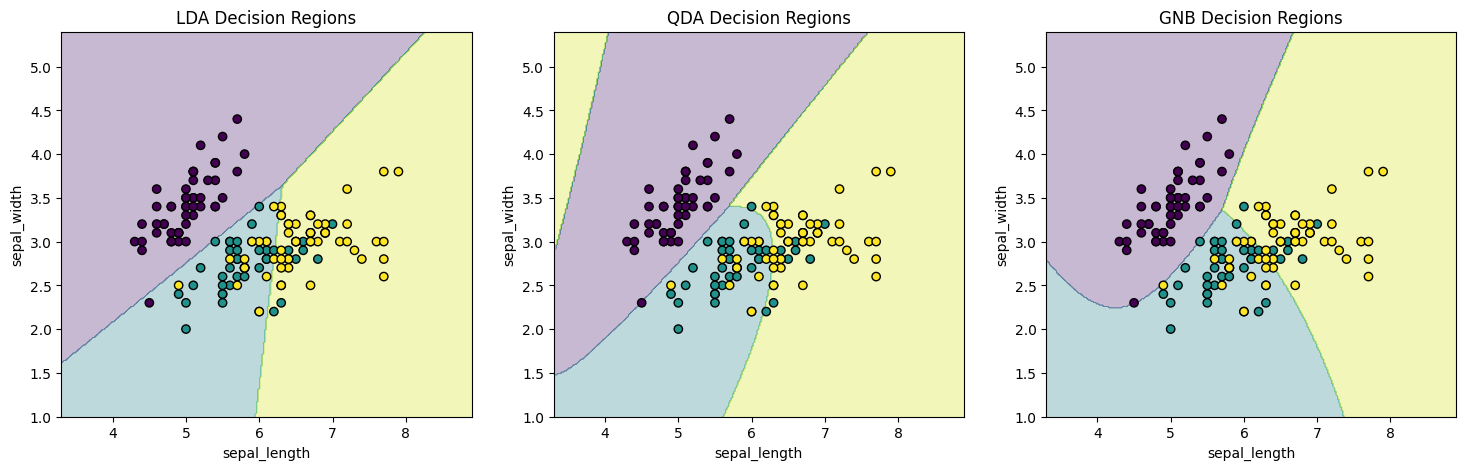

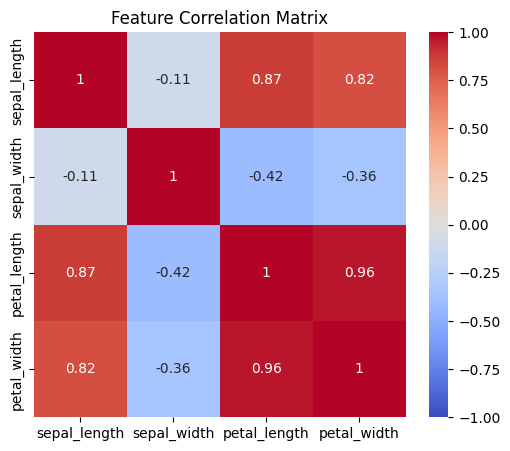

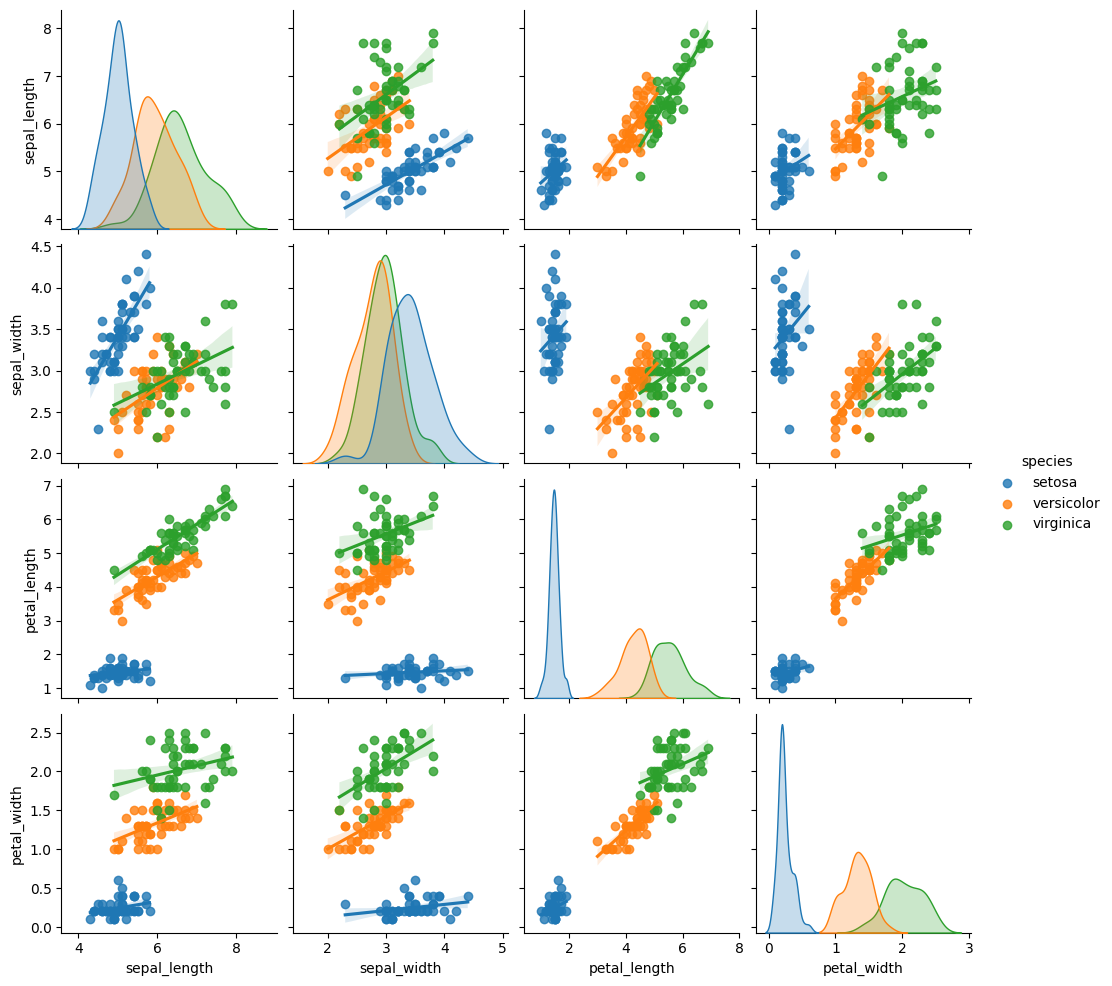

Pearson correlation tests (linear regression p-values):
sepal_length vs sepal_width: p-value = 1.828e-01
sepal_length vs petal_length: p-value = 1.038e-47
sepal_length vs petal_width: p-value = 2.315e-37
sepal_width vs petal_length: p-value = 8.429e-08
sepal_width vs petal_width: p-value = 7.524e-06
petal_length vs petal_width: p-value = 5.777e-86
LDA Test Accuracy: 0.978
QDA Test Accuracy: 0.978
GNB Test Accuracy: 1.000


In [157]:
# GNB, LDA, QDA decision boundaries + feature correlation + hypothesis tests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
import statsmodels.api as sm

# Load Iris dataset
iris = pd.read_csv('data/iris.csv')
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris[feature_names].values
y = LabelEncoder().fit_transform(iris['species'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Fit models
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
gnb = GaussianNB().fit(X_train, y_train)

# Visualize decision boundaries (2D projection: first two features)
X_vis = X[:, :2]
lda_2d = LinearDiscriminantAnalysis().fit(X_train[:, :2], y_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_train[:, :2], y_train)
gnb_2d = GaussianNB().fit(X_train[:, :2], y_train)

xx, yy = np.meshgrid(
    np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 300),
    np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lda = lda_2d.predict(grid).reshape(xx.shape)
Z_qda = qda_2d.predict(grid).reshape(xx.shape)
Z_gnb = gnb_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(18,5))
models = [('LDA', Z_lda), ('QDA', Z_qda), ('GNB', Z_gnb)]
for i, (name, Z) in enumerate(models, 1):
    plt.subplot(1,3,i)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_vis[:,0], X_vis[:,1], c=y, edgecolor='k')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f"{name} Decision Regions")
plt.show()

# Feature correlation heatmap
corr = pd.DataFrame(X, columns=feature_names).corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

# Pairplot for visual inspection
sns.pairplot(iris, hue="species", kind='reg', diag_kind='kde',vars=feature_names)
plt.show()

# Hypothesis tests for linear correlation using statsmodels OLS
print("Pearson correlation tests (linear regression p-values):")
for i in range(X.shape[1]):
    for j in range(i+1, X.shape[1]):
        X_j = sm.add_constant(X[:,i])
        model = sm.OLS(X[:,j], X_j).fit()
        p_value = model.pvalues[1]  # coefficient of X_i
        print(f"{feature_names[i]} vs {feature_names[j]}: p-value = {p_value:.3e}")

# Now compare model accuracies
models = {'LDA': lda, 'QDA': qda, 'GNB': gnb}
for name, model in models.items():
    accuracy = model.score(X_test, y_test)
    print(f"{name} Test Accuracy: {accuracy:.3f}")


## Comparison of Logistic Regression, LDA, QDA, and Naive Bayes

### Method Overview

| Method | Approach | Flexibility / Degrees of Freedom | Advantages | Disadvantages |
|--------|---------|---------------------------------|------------|---------------|
| **Logistic Regression** | Discriminative: directly models P(Y/X) via iterative Maximum Likelihood | Few parameters (linear boundary) | Interpretable, robust for small n, directly models decision boundary | Assumes linear separation; may not converge on perfectly separable data without regularization |
| **LDA (Linear Discriminant Analysis)** | Generative: models P(X/Y) as Gaussian with shared covariance, applies Bayes rule | Few parameters (shared covariance) | Efficient for small n, linear boundary, simple computation | Only linear boundaries; assumes equal class covariances |
| **QDA (Quadratic Discriminant Analysis)** | Generative: models P(X/Y) as Gaussian with class-specific covariance | More parameters (one covariance per class) | Flexible, can model quadratic boundaries | Higher variance with small n; needs enough data to estimate covariance matrices reliably |
| **Naive Bayes** | Generative: models P(X|Y) assuming feature independence | Very few parameters (mean/variance per feature per class) | Very efficient, works well in high dimensions, robust for small n | Strong independence assumption often violated; probabilities can be biased |

### Key Points / Discussion

1. **Discriminative vs. Generative**  
   - Logistic Regression is discriminative: directly models P(Y|X) and optimizes class assignment.  
   - LDA, QDA, and Naive Bayes are generative: model P(X|Y) and use Bayes' theorem to derive P(Y|X).

2. **Bias-Variance Tradeoff**  
   - LDA: low variance, higher bias (fewer parameters, shared covariance)  
   - QDA: higher variance, lower bias (class-specific covariance)  
   - Naive Bayes: minimal variance, strong bias due to independence assumption  
   - Logistic Regression: moderate variance/bias, depends on regularization and linearity of boundary

3. **Practical Considerations**  
   - Choice depends on the number of predictors (p), number of training observations (n), and how well model assumptions match reality.  
   - Logistic Regression is often preferred when interpretability and direct modeling of decision boundaries matter.  
   - LDA is efficient with small n and roughly equal class covariances.  
   - QDA is flexible for nonlinear boundaries but needs larger datasets.  
   - Naive Bayes excels in high-dimensional, sparse, or text-like data where independence assumptions are reasonable.

4. **Additional Aspects / Wrap-Up**  
   - Logistic Regression can be regularized (L1/L2) to stabilize estimation on separable data.  
   - LDA/QDA assume Gaussian feature distributions; performance drops if violated.  
   - Naive Bayes can still perform surprisingly well even when independence assumptions are not strictly met.  
   - No single method is universally best; understanding data structure, sample size, and feature properties is crucial.

### Summary
Discriminative vs. generative modeling, flexibility, and assumptions drive the choice of method:

- Logistic Regression: discriminative, interpretable, linear boundaries.  
- LDA: generative, linear, efficient for small n, assumes shared covariance.  
- QDA: generative, flexible quadratic boundaries, requires more data.  
- Naive Bayes: generative, simple, robust in high dimensions, strong independence assumptions.


## Generalized Linear Models (GLMs)

### Key Idea
Generalized Linear Models (GLMs) extend classical linear regression to response variables
that are **not normally distributed** by combining:
1. a linear predictor,
2. a link function,
3. a probability distribution from the exponential family.

They provide a unified framework for many commonly used statistical models.

See: https://www.youtube.com/watch?v=Obpz_Uvo2rQ for rather easy example
---

### Components of a GLM

1. **Random component**  
   The conditional distribution of the response variable:
   $$
   Y \mid X \sim \text{Exponential Family}
   $$
   Examples:
   - Gaussian → linear regression
   - Bernoulli → binary logistic regression
   - Multinomial → multinomial logistic regression
   - Poisson → count data regression

2. **Systematic component (linear predictor)**  
   $$
   \eta = \beta_0 + \beta^T X
   $$

3. **Link function**  
   A monotone function $g(\cdot)$ that connects the mean response to the linear predictor:
   $$
   g\!\left(\mathbb{E}[Y \mid X]\right) = \eta
   $$

---

### Common GLMs

| Model | Response Distribution | Link Function |
|------|----------------------|---------------|
| Linear Regression | Gaussian | Identity |
| Logistic Regression | Bernoulli | Logit |
| Multinomial Logistic Regression | Multinomial | Softmax / Logit |
| Poisson Regression | Poisson | Log |

---

### Estimation

- Parameters are estimated by **maximum likelihood**.
- No closed-form solution in general → iterative optimization (e.g. IRLS, gradient-based methods).
- Regularization (L1/L2) integrates naturally into the GLM framework.

---

### Strengths of GLMs

- Unified probabilistic framework
- Interpretable parameters
- Well-understood asymptotic theory
- Extendable via regularization, offsets, and weights

---

### Limitations of GLMs

- Linear predictor limits expressiveness
- Requires correct choice of link and distribution
- Can fail under perfect or near-perfect separation
- Nonlinear boundaries require feature engineering or other model classes

---

### Takeaway

> Generalized Linear Models unify linear and logistic regression into a single framework.
> Logistic regression is a special case of a GLM, while LDA, QDA, and Naive Bayes are outside
> the GLM framework as generative models.
> GLMs model $P(Y \mid X)$ directly via a link function, whereas generative classifiers model
> $P(X \mid Y)$ and infer $P(Y \mid X)$ using Bayes’ theorem.


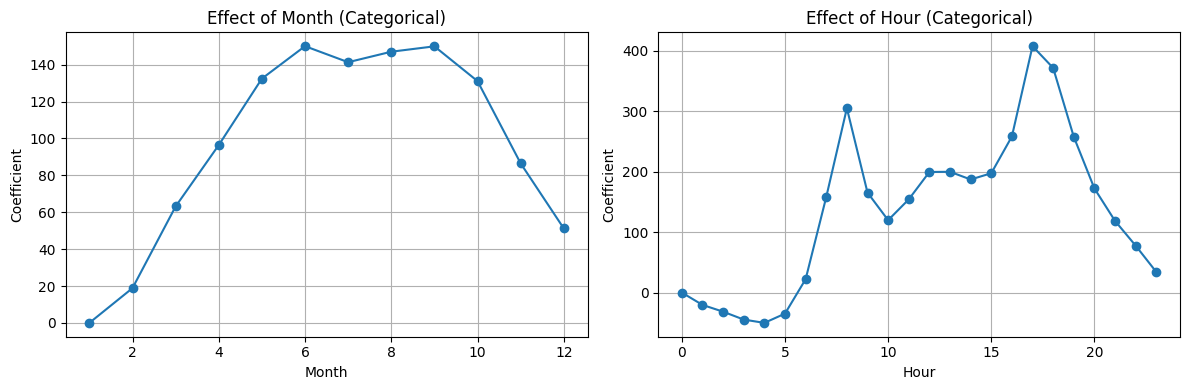

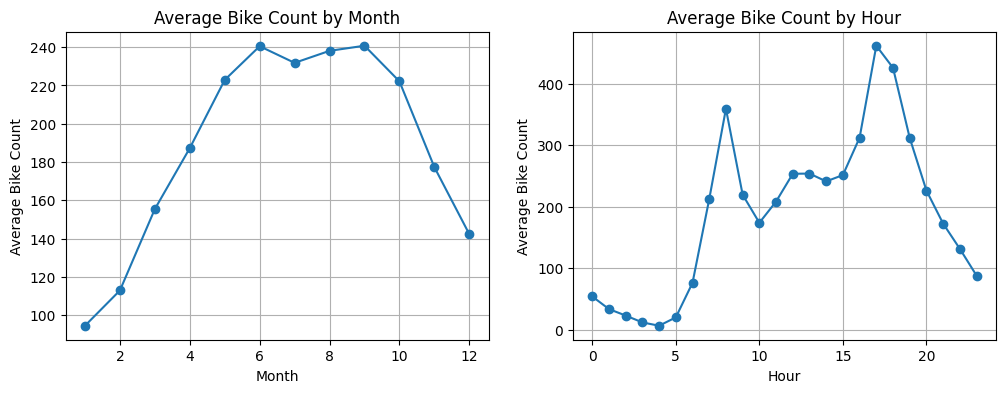

In [163]:
# === ISLR Figure 4.13: Linear Regression with Categorical Month and Hour ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
bikeshare = pd.read_csv('data/bike_hour.csv')

# Response
y = bikeshare['cnt'].values

# Categorical encoding for month and hour (baseline: month=1, hour=0)
X_cat = pd.get_dummies(
    bikeshare[['mnth', 'hr']],
    columns=['mnth', 'hr'],
    drop_first=True
)

# Design matrix with intercept
X_design = np.hstack([
    np.ones((X_cat.shape[0], 1)),
    X_cat.values
])



# Fit linear regression (OLS)
beta_hat = np.linalg.lstsq(X_design, y, rcond=None)[0]

# ------------------------------------------------------------
# Extract coefficient effects (ISLR-style)
# ------------------------------------------------------------

# Month effects (month 1 is baseline = 0)
month_effect = np.zeros(12)
for m in range(2, 13):
    col = f"mnth_{m}"
    idx = X_cat.columns.get_loc(col)
    month_effect[m-1] = beta_hat[idx + 1]  # +1 for intercept

# Hour effects (hour 0 is baseline = 0)
hour_effect = np.zeros(24)
for h in range(1, 24):
    col = f"hr_{h}"
    idx = X_cat.columns.get_loc(col)
    hour_effect[h] = beta_hat[idx + 1]

# ------------------------------------------------------------
# Plot effects
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, 13), month_effect, marker='o')
plt.xlabel("Month")
plt.ylabel("Coefficient")
plt.title("Effect of Month (Categorical)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(24), hour_effect, marker='o')
plt.xlabel("Hour")
plt.ylabel("Coefficient")
plt.title("Effect of Hour (Categorical)")
plt.grid(True)

plt.tight_layout()
plt.show()


# Now plot the actual bike counts by month and hour to compare
bikes_by_month = bikeshare.groupby('mnth')['cnt'].mean()
bikes_by_hour = bikeshare.groupby('hr')['cnt'].mean()
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(bikes_by_month.index, bikes_by_month.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Average Bike Count")
plt.title("Average Bike Count by Month")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(bikes_by_hour.index, bikes_by_hour.values, marker='o')
plt.xlabel("Hour")
plt.ylabel("Average Bike Count")
plt.title("Average Bike Count by Hour")
plt.grid(True)

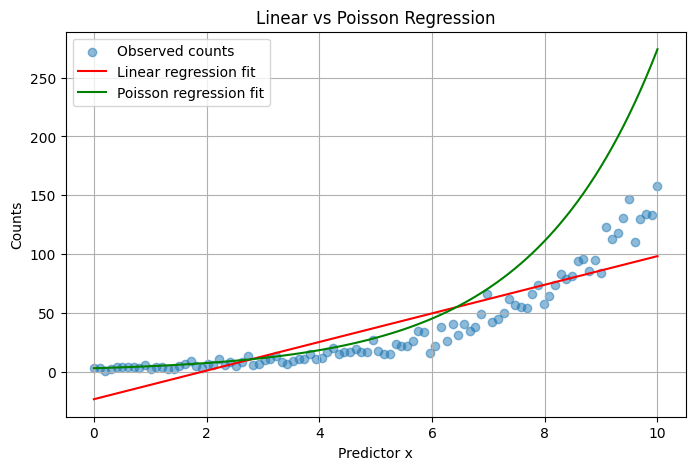

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# -----------------------------
# 1. Synthetic example
# -----------------------------
x = np.linspace(0, 10, 100)    # predictor
beta_0 = 1.0
beta_1 = 0.4

# Linear predictor (η)
eta = beta_0 + beta_1 * x

# Poisson mean via log-link (λ = exp(η))
lambda_ = np.exp(eta)

# Generate "observed counts" with Poisson noise
y_counts = np.random.poisson(lambda_)

# -----------------------------
# 2. Fit linear regression to raw counts (wrong approach)
# -----------------------------
X_lin = np.vstack([np.ones_like(x), x]).T
beta_lin = np.linalg.lstsq(X_lin, y_counts, rcond=None)[0]
y_lin_pred = X_lin @ beta_lin

# -----------------------------
# 3. Fit Poisson regression via log-link (gradient ascent)
# -----------------------------
def poisson_log_likelihood(X, y, beta):
    eta = X @ beta
    mu = np.exp(eta)
    return np.sum(y * eta - mu)

def poisson_gradient_ascent(X, y, lr=1e-5, max_iter=10000, tol=1e-6):
    beta = np.zeros(X.shape[1])
    for i in range(max_iter):
        eta = X @ beta
        mu = np.exp(eta)
        grad = X.T @ (y - mu)
        beta_new = beta + lr * grad
        if np.linalg.norm(beta_new - beta) < tol:
            break
        beta = beta_new
    return beta

beta_poisson = poisson_gradient_ascent(X_lin, y_counts)
y_poisson_pred = np.exp(X_lin @ beta_poisson)

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(x, y_counts, label='Observed counts', alpha=0.5)
plt.plot(x, y_lin_pred, label='Linear regression fit', color='red')
plt.plot(x, y_poisson_pred, label='Poisson regression fit', color='green')
plt.xlabel("Predictor x")
plt.ylabel("Counts")
plt.title("Linear vs Poisson Regression")
plt.legend()
plt.grid(True)
plt.show()


## Guideline for Approaching a Classification Problem

### Understand the Data
- Explore the dataset: feature types (categorical, numerical), missing values, class balance.
- Visualize distributions, correlations, and potential class separability.

### Baseline Models
- Start with simple models to establish a baseline: 
  - Logistic Regression
  - LDA / Naive Bayes
- Assess performance using cross-validation metrics (accuracy,  ROC-AUC).

### Model Selection
- Choose models based on data characteristics:
  - **Logistic Regression**: interpretable, works well with small n, linear boundary.
  - **LDA**: linear boundary, efficient for small n, assumes shared covariance --> Analyze covariances in train data.
  - **QDA**: flexible, can model nonlinear boundaries, needs more data --> Analyze covariances in train data to justify more complex model over LDA
  - **Naive Bayes**: robust for high-dimensional or sparse data.


###  Model Evaluation
- Split data into training/validation/test sets or use k-fold cross-validation.
- Use multiple metrics (ROC-AUC) depending on class balance and business context.

**Key Takeaway:**  
There is no single “best” model for every classification problem. The choice depends on:
- Number of features (p) and observations (n)
- Underlying data distribution
- Desired interpretability
- Flexibility vs. risk of overfitting (bias-variance tradeoff)
